In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── FILE PATHS ───────────────────────────────────────────────────────────────
FILES = {
    '1B':  'mega_1_lama_instruct.csv',
    '8B':  'mega_8_lama_instruct.csv',
    '70B': 'mega_70_lama_instruct.csv',
}

# ── CONFIDENCE METRICS + SCALE FACTORS ──────────────────────────────────────
# scale=100 converts 0-1 range to 0-100 for plotting; verbal stays as-is (1)
CONF_METRICS = {
    'Entropy_as_confidence':  100,
    'Letter_MSP_confidence':  100,
    'Margin_renorm_ABCD':     100,
    'verbal_integer_found':     1,
    'p1_probability':         100,
    'p_true_probability':     100,
}

CONF_LABELS = {
    'Entropy_as_confidence': 'Entropy as Confidence',
    'Letter_MSP_confidence': 'MSP',
    'Margin_renorm_ABCD':    'Margin (Normalised)',
    'verbal_integer_found':  'Verbal',
    'p1_probability':        'P(1)',
    'p_true_probability':    'P(True)',
}

CONF_COLORS = {
    'Entropy_as_confidence': '#e41a1c',
    'Letter_MSP_confidence': '#377eb8',
    'Margin_renorm_ABCD':    '#4daf4a',
    'verbal_integer_found':  '#ff7f00',
    'p1_probability':        '#984ea3',
    'p_true_probability':    '#a65628',
}

MODEL_SIZES = list(FILES.keys())

# ── LOAD & CLEAN ─────────────────────────────────────────────────────────────
print('=' * 60)
print('DATA LOADING & ROW EXCLUSION REPORT')
print('=' * 60)

dfs = {}
for label, path in FILES.items():
    #go through each file's csv/ for each csv
    #put the csv into a dataframe
    df_raw = pd.read_csv(path)
    #see how big the dataframe is
    total = len(df_raw)
    mask_blank = (
        df_raw['letter_llm_outputted_detected'].isna() |
        (df_raw['letter_llm_outputted_detected'].astype(str).str.strip() == '')
    )
    #find out how many rows are NA/didn't output correctly
    n_excluded = mask_blank.sum()
    #remove thoughs blank rows
    df_clean = df_raw[~mask_blank].copy()
    dfs[label] = df_clean
    #print the total rows before, detected, and afer (show in percentage how much was kept)
    print(f'  Model {label:>3s}: {total:>5d} rows total  |  '
          f'{n_excluded:>3d} excluded (no letter detected)  |  '
          f'{len(df_clean):>5d} kept ({100*len(df_clean)/total:.1f}%)')

print('=' * 60)


DATA LOADING & ROW EXCLUSION REPORT
  Model  1B:  6233 rows total  |    1 excluded (no letter detected)  |   6232 kept (100.0%)
  Model  8B:  6233 rows total  |    0 excluded (no letter detected)  |   6233 kept (100.0%)
  Model 70B:  6233 rows total  |    0 excluded (no letter detected)  |   6233 kept (100.0%)


In [ ]:
#we created a single data frame called dfs which is a dciotrnary
#the key is the size of the model
#the value is the cleaned dataframe of that model

In [2]:
with pd.option_context('display.max_columns', None):
    display(df_clean.head())

,Question,Choices,correct_letter,llm_first_token_output,letter_llm_outputted_detected,pass1_10_token_generation,Letter_MSP,Letter_MSP_confidence,is_correct,check_letter_output_is_highest_MSP,prob_A,prob_B,prob_C,prob_D,Raw_Entropy,Entropy_as_confidence,Margin_softmax_full_vocab,Margin_renorm_ABCD,Top_2_Tokens,p_true_raw_output,p_true_probability,p1_raw_output,p1_probability,verbal_full_text_generated,verbal_integer_found,Category,Model
0,Find the degree for the given field extension ...,"['0', '4', '2', '6']",B,B,B,B,B,0.909560,True,True,0.001065,0.909560,0.004773,0.084602,0.327972,0.763419,0.822541,8.249575e-01,"[' B', ' D']",A,0.962673,1,0.622459,0\n\nThe correct answer is not B.,0,abstract_algebra,Llama-3.1-70B-INSTRUCT
1,"Let p = (1, 2, 5, 4)(2, 3) in S_5 . Find the i...","['8', '2', '24', '120']",C,B,B,B,B,0.474070,False,True,0.153908,0.474070,0.197622,0.174401,1.266867,0.086149,0.275848,2.764480e-01,"[' B', ' C']",A,0.622459,0,0.201813,0\n\nThe previous answer was incorrect. To find,0,abstract_algebra,Llama-3.1-70B-INSTRUCT
2,Find all zeros in the indicated finite field o...,"['0', '1', '0,1', '0,4']",D,D,D,D,D,0.654368,True,True,0.060866,0.011985,0.272781,0.654368,0.855266,0.383056,0.380375,3.815866e-01,"[' D', ' C']",A,0.998499,1,0.851953,100\n\nExplanation: To find the zeros of the,100,abstract_algebra,Llama-3.1-70B-INSTRUCT
3,Statement 1 | A factor group of a non-Abelian ...,"['True, True', 'False, False', 'True, False', ...",B,D,D,D,D,0.766981,False,True,0.080839,0.071340,0.080839,0.766981,0.798503,0.424002,0.677496,6.861418e-01,"[' D', ' C']",A,0.731059,1,0.679179,100\n\nExplanation: \nStatement 1 is false,100,abstract_algebra,Llama-3.1-70B-INSTRUCT
4,Find the product of the given polynomials in t...,"['2x^2 + 5', '6x^2 + 4x + 6', '0', 'x^2 + 1']",B,C,C,C,B,0.486607,False,False,0.021380,0.486607,0.486607,0.005406,0.811437,0.414672,0.000000,2.426081e-07,"[' B', ' C']",A,0.946597,0,0.468791,0\n\nExplanation: The previous answer was inco...,0,abstract_algebra,Llama-3.1-70B-INSTRUCT


In [3]:
df_clean.shape

(6233, 27)

In [4]:
MODEL_SIZES

['1B', '8B', '70B']

In [5]:
# ── COMPUTE AVERAGES (scaled to 0-100 for plotting & printing) ───────────────
accuracy_scores   = []                            # list, one value per model
confidence_scores = {col: [] for col in CONF_METRICS}

#For eahc model size = the key values of dfs (main dataframe)
for name in MODEL_SIZES:
    #get that models dataframe
    df = dfs[name]
    #see how many correct answer it got (make it into percentange)
    acc = df['is_correct'].astype(int).mean() * 100
    #append to list above for plotting
    accuracy_scores.append(acc)
    for col, scale in CONF_METRICS.items():
        #for each of the confidence metrics defined above, need to find the average (also scale it appropriately to make into percentaged)
        #The scaling is written above
        #So this goes through each of the confidence metric columns, finds the mean, scales, and then appends to list for plotting
        avg = pd.to_numeric(df[col], errors='coerce').mean() * scale
        #appends to list for plotting
        confidence_scores[col].append(avg)

# ── PRINT AVERAGES SUMMARY ───────────────────────────────────────────────────
print('\n' + '=' * 65)
#print out the averages (The number are just to align printing the averages/ nothing to do with actual average number)
####This is just the column
print(f"{'MODEL SIZE':<12} | {'METRIC':<28} | {'AVG SCORE':>10}")
print('-' * 65)

for i, name in enumerate(MODEL_SIZES):
    #this fills in the columns with the values going through the list (confidence_scores and accuracy_scores)
    #for each of the sizes
    #using the order in which we appended them to find out the model size (Same order so 1 = 1, 2=8, 3=70)
    print(f"{name:<12} | {'Accuracy (Target)':<28} | {accuracy_scores[i]:>9.2f}%")
    for col in CONF_METRICS:
        val    = confidence_scores[col][i]
        gap    = val - accuracy_scores[i]
        status = '(Overconfident)' if gap > 0 else '(Underconfident)'
        lbl    = CONF_LABELS[col]
        print(f"{'':12} | {lbl:<28} | {val:>9.2f}%  {status}")
    print('-' * 65)

print('=' * 65 + '\n')



MODEL SIZE   | METRIC                       |  AVG SCORE
-----------------------------------------------------------------
1B           | Accuracy (Target)            |     46.07%
             | Entropy as Confidence        |     30.32%  (Underconfident)
             | MSP                          |     58.79%  (Overconfident)
             | Margin (Normalised)          |     37.81%  (Underconfident)
             | Verbal                       |     12.73%  (Underconfident)
             | P(1)                         |     37.08%  (Underconfident)
             | P(True)                      |     55.24%  (Overconfident)
-----------------------------------------------------------------
8B           | Accuracy (Target)            |     67.19%
             | Entropy as Confidence        |     64.57%  (Underconfident)
             | MSP                          |     80.13%  (Overconfident)
             | Margin (Normalised)          |     67.69%  (Overconfident)
             | Verbal    

In [6]:
CONF_LABELS

{'Entropy_as_confidence': 'Entropy as Confidence',
 'Letter_MSP_confidence': 'MSP',
 'Margin_renorm_ABCD': 'Margin (Normalised)',
 'verbal_integer_found': 'Verbal',
 'p1_probability': 'P(1)',
 'p_true_probability': 'P(True)'}

In [7]:
CONF_METRICS

{'Entropy_as_confidence': 100,
 'Letter_MSP_confidence': 100,
 'Margin_renorm_ABCD': 100,
 'verbal_integer_found': 1,
 'p1_probability': 100,
 'p_true_probability': 100}

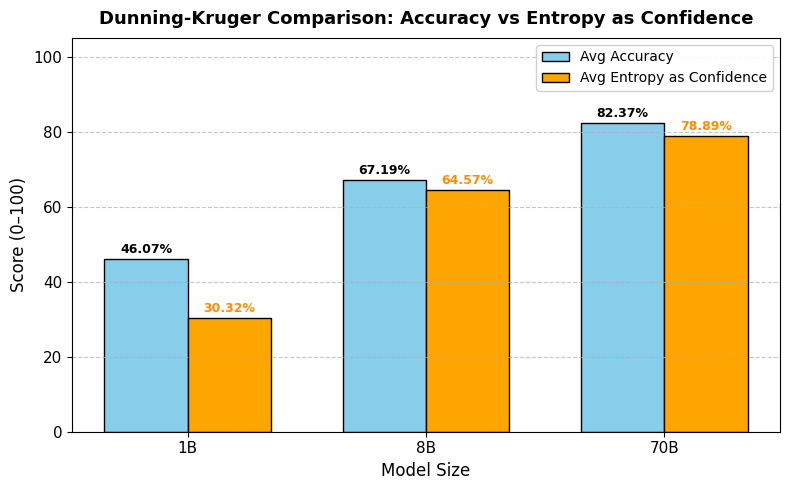

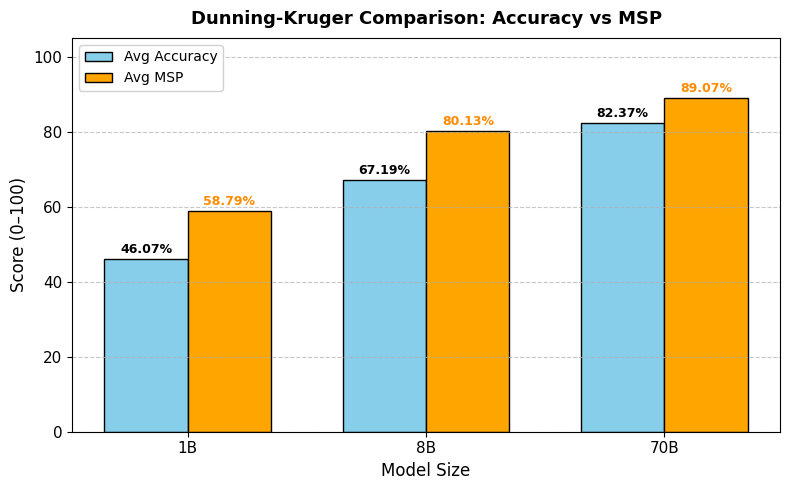

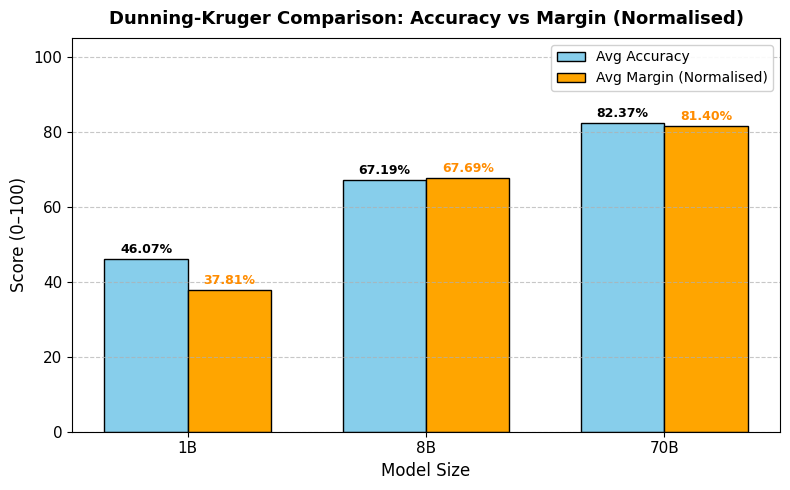

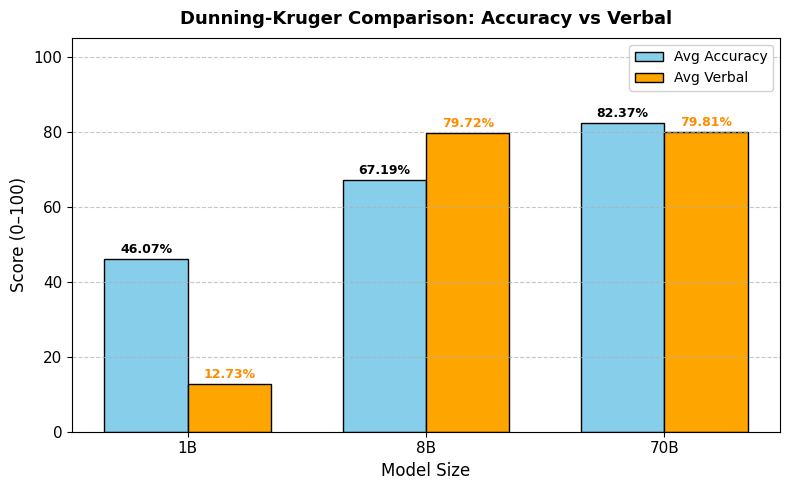

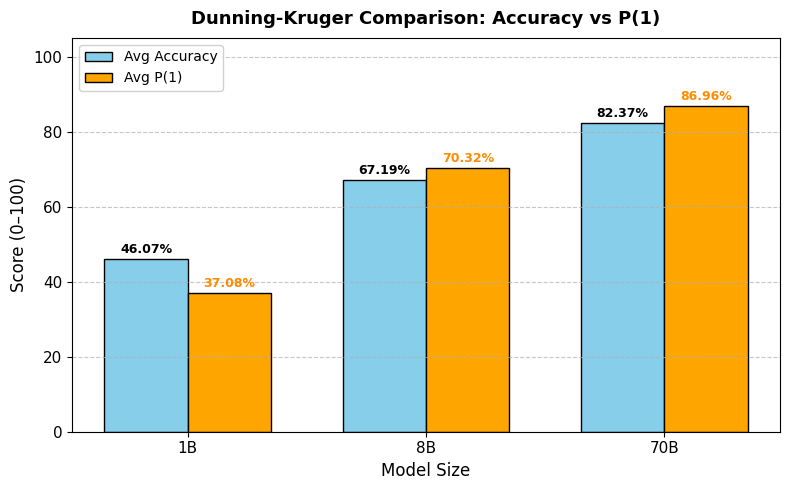

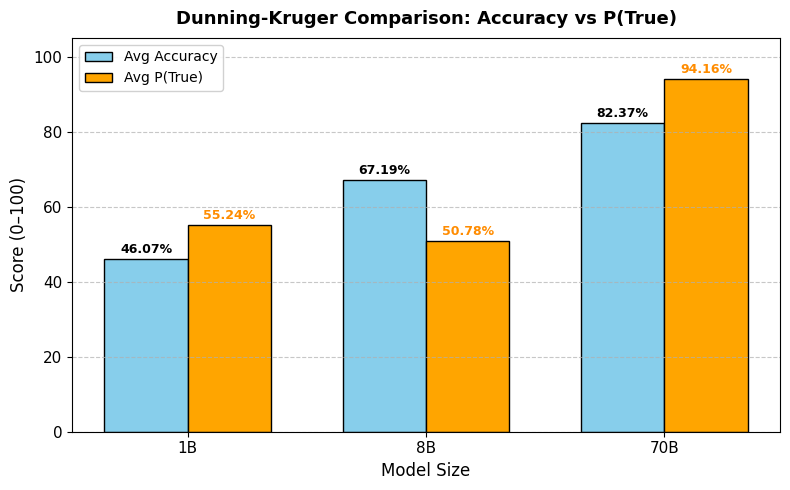

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
#  INDIVIDUAL BAR CHARTS — one per confidence metric
#  Accuracy (skyblue) vs Confidence (orange), Y-axis 0-105
# ═══════════════════════════════════════════════════════════════════════════

x     = np.arange(len(MODEL_SIZES))
width = 0.35

for col in CONF_METRICS:
   #for each confidence metric 
    lbl = CONF_LABELS[col]
    #lbl will be the label we want (e.g. without the dashes)
    fig, ax = plt.subplots(figsize=(8, 5))

    #first bar chart will be accuracy scores
    bars_acc  = ax.bar(x - width/2, accuracy_scores, width,
                       label='Avg Accuracy', color='skyblue', edgecolor='black')
    #second bar chart will be confidence metrics
    #both accuracy_scores and confidence_scores are stored as lists which we can display
    bars_conf = ax.bar(x + width/2, confidence_scores[col], width,
                       label=f'Avg {lbl}', color='orange', edgecolor='black')

    for bar in bars_acc:
        #go through that list and plot each accuracy bar
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                f'{h:.2f}%', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='black')
    for bar in bars_conf:
       #for the same index/model then plot next to it, it's confidence bar 
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8,
                f'{h:.2f}%', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='darkorange')

    ax.set_title(f'Dunning-Kruger Comparison: Accuracy vs {lbl}',
                 fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Score (0–100)', fontsize=12)
    ax.set_xlabel('Model Size', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_SIZES, fontsize=12)
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g'))
    ax.tick_params(axis='both', labelsize=11)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    fig.tight_layout()
    plt.show()


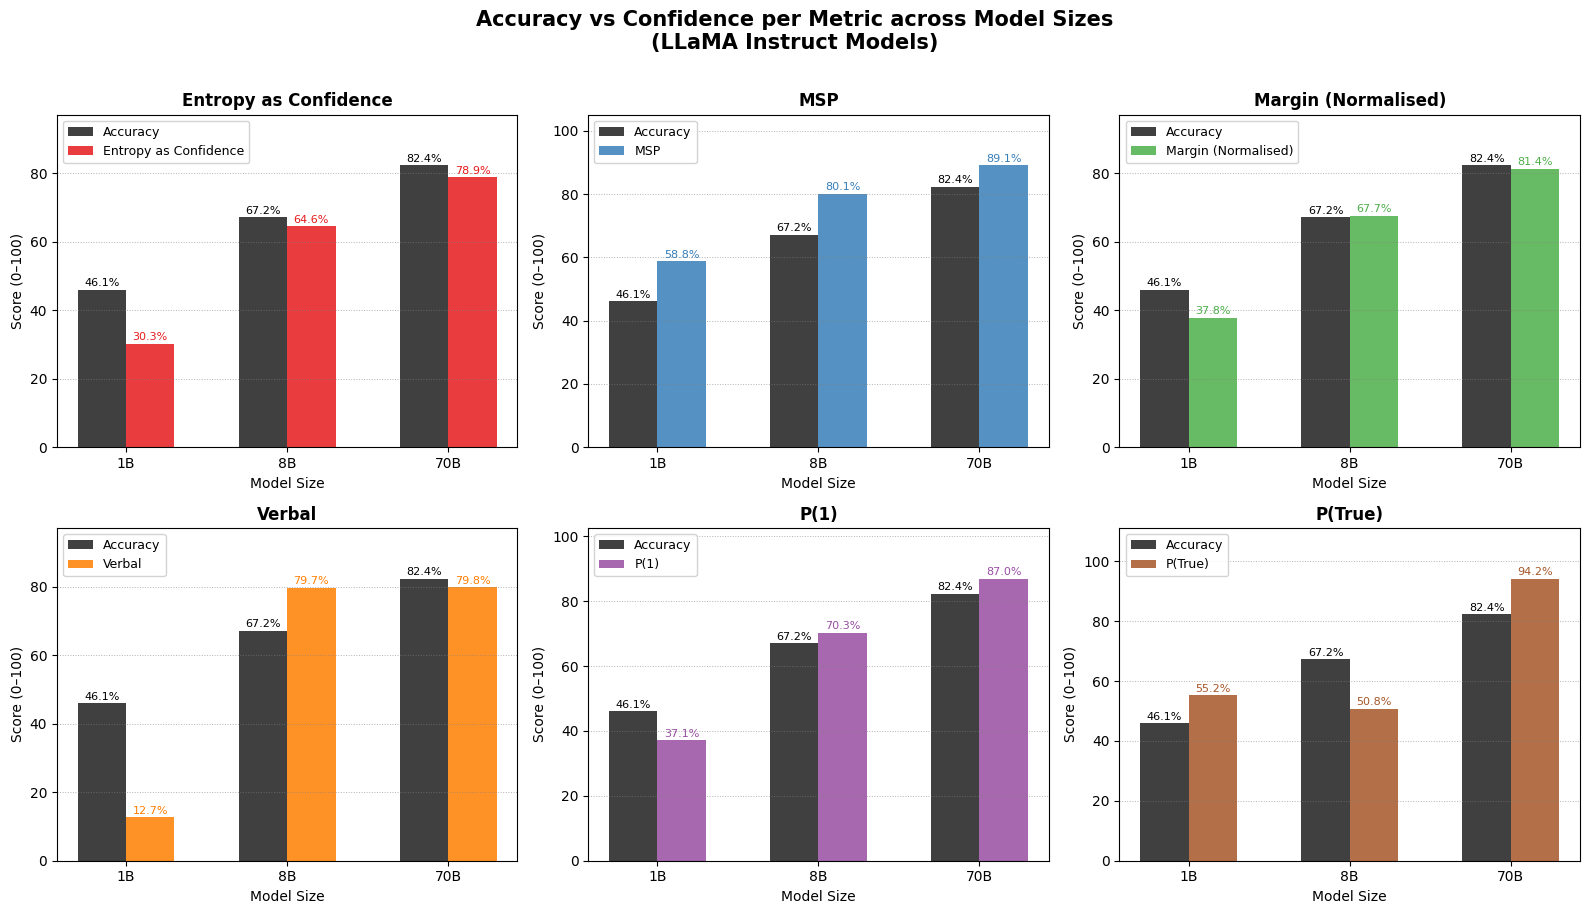

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
#  GROUPED BAR CHARTS — 2x3 grid, one subplot per metric
#  Black = Accuracy, Coloured = Confidence metric
# ═══════════════════════════════════════════════════════════════════════════

#same thing as above but all in one bar chart that is pretty
fig2, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
axes = axes.flatten()

bar_width = 0.3
x = np.arange(len(MODEL_SIZES))

for idx, col in enumerate(CONF_METRICS):
    ax = axes[idx]
    lbl = CONF_LABELS[col]

    bars_acc  = ax.bar(x - bar_width/2, accuracy_scores, bar_width,
                       color='black', alpha=0.75, label='Accuracy')
    bars_conf = ax.bar(x + bar_width/2, confidence_scores[col], bar_width,
                       color=CONF_COLORS[col], alpha=0.85, label=lbl)

    for bar in bars_acc:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8, color='black')
    for bar in bars_conf:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8,
                color=CONF_COLORS[col])

    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_SIZES, fontsize=11)
    ax.set_title(lbl, fontsize=12, fontweight='bold', pad=6)
    ax.set_xlabel('Model Size', fontsize=10)
    ax.set_ylabel('Score (0–100)', fontsize=10)
    ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.6, color='grey')
    ax.tick_params(axis='both', labelsize=10)
    ax.legend(fontsize=9, framealpha=0.85)
    ax.set_ylim(0, max(max(accuracy_scores), max(confidence_scores[col])) * 1.18)

fig2.suptitle('Accuracy vs Confidence per Metric across Model Sizes\n(LLaMA Instruct Models)',
              fontsize=15, fontweight='bold', y=1.01)
fig2.tight_layout()
plt.show()

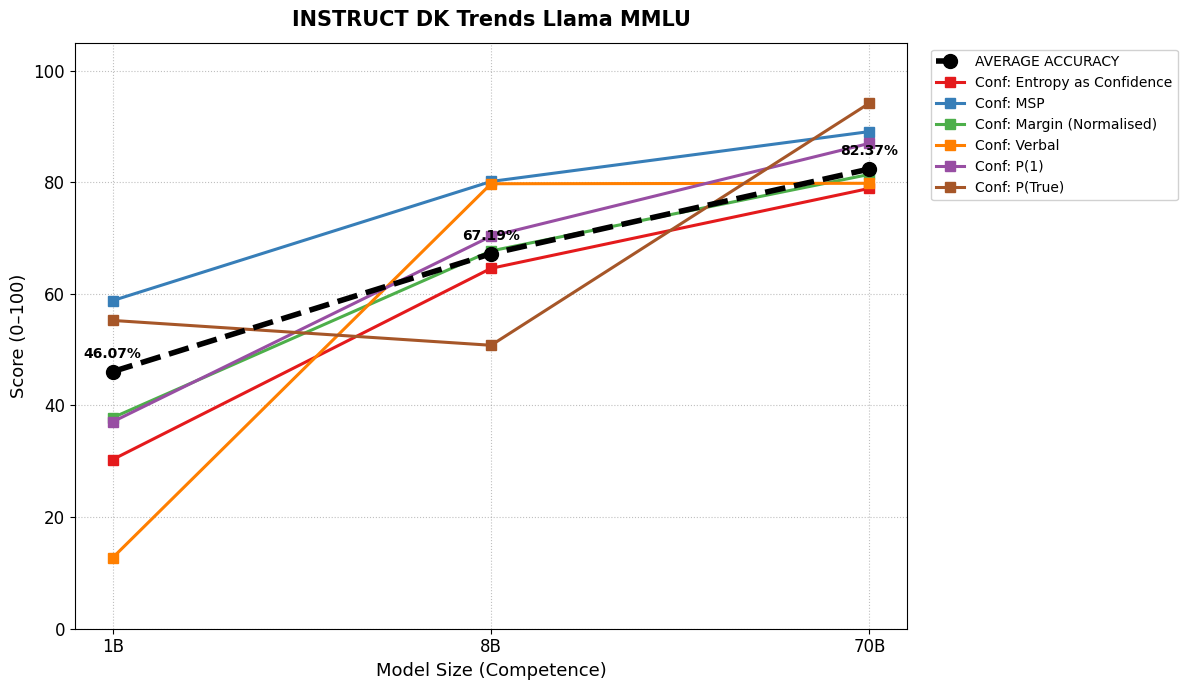

In [10]:
# ═══════════════════════════════════════════════════════════════════════════
#  COMBINED LINE CHART — Inter Dunning-Kruger Curve
#  Black dashed = Accuracy  |  Coloured lines = each confidence metric
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 7))

# accuracy — thick black dashed
ax.plot(MODEL_SIZES, accuracy_scores,
        marker='o', linewidth=4, markersize=10,
        label='AVERAGE ACCURACY', color='black', linestyle='--', zorder=5)
#the x-axis will be model size 
#black line will be accuracy scores for that x-axis

# annotate accuracy values above each point
#Add the number of accuracy values
for i, v in enumerate(accuracy_scores):
    ax.annotate(f'{v:.2f}%', xy=(i, v), xytext=(0, 10),
                textcoords='offset points', ha='center',
                fontsize=10, fontweight='bold', color='black')

# confidence metrics — coloured
for col in CONF_METRICS:
    #for each confidence metric plot the line (Each point will be one model size)
    lbl = CONF_LABELS[col]
    #this words because confidence_scores is a list and order will naturally follow model_size x-axis
    ax.plot(MODEL_SIZES, confidence_scores[col],
            marker='s', linewidth=2.2, markersize=7,
            label=f'Conf: {lbl}', color=CONF_COLORS[col])

ax.set_title('INSTRUCT DK Trends Llama MMLU',
             fontsize=15, fontweight='bold', pad=12)
ax.set_ylabel('Score (0–100)', fontsize=13)
ax.set_xlabel('Model Size (Competence)', fontsize=13)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g'))
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, linestyle=':', alpha=0.5, color='grey')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=10, framealpha=0.9, edgecolor='#cccccc')
fig.tight_layout()
plt.savefig(
    'llama_mmlu_instruct_2.png', 
    dpi=300,                  # High resolution for print/PDF dissertations (600 is also an option)
    bbox_inches='tight',      # Automatically crops unnecessary white space and ensures text isn't cut off
    facecolor='white',        # Ensures the saved image background is solid white, not gray or transparent
    edgecolor='none'
)
plt.show()


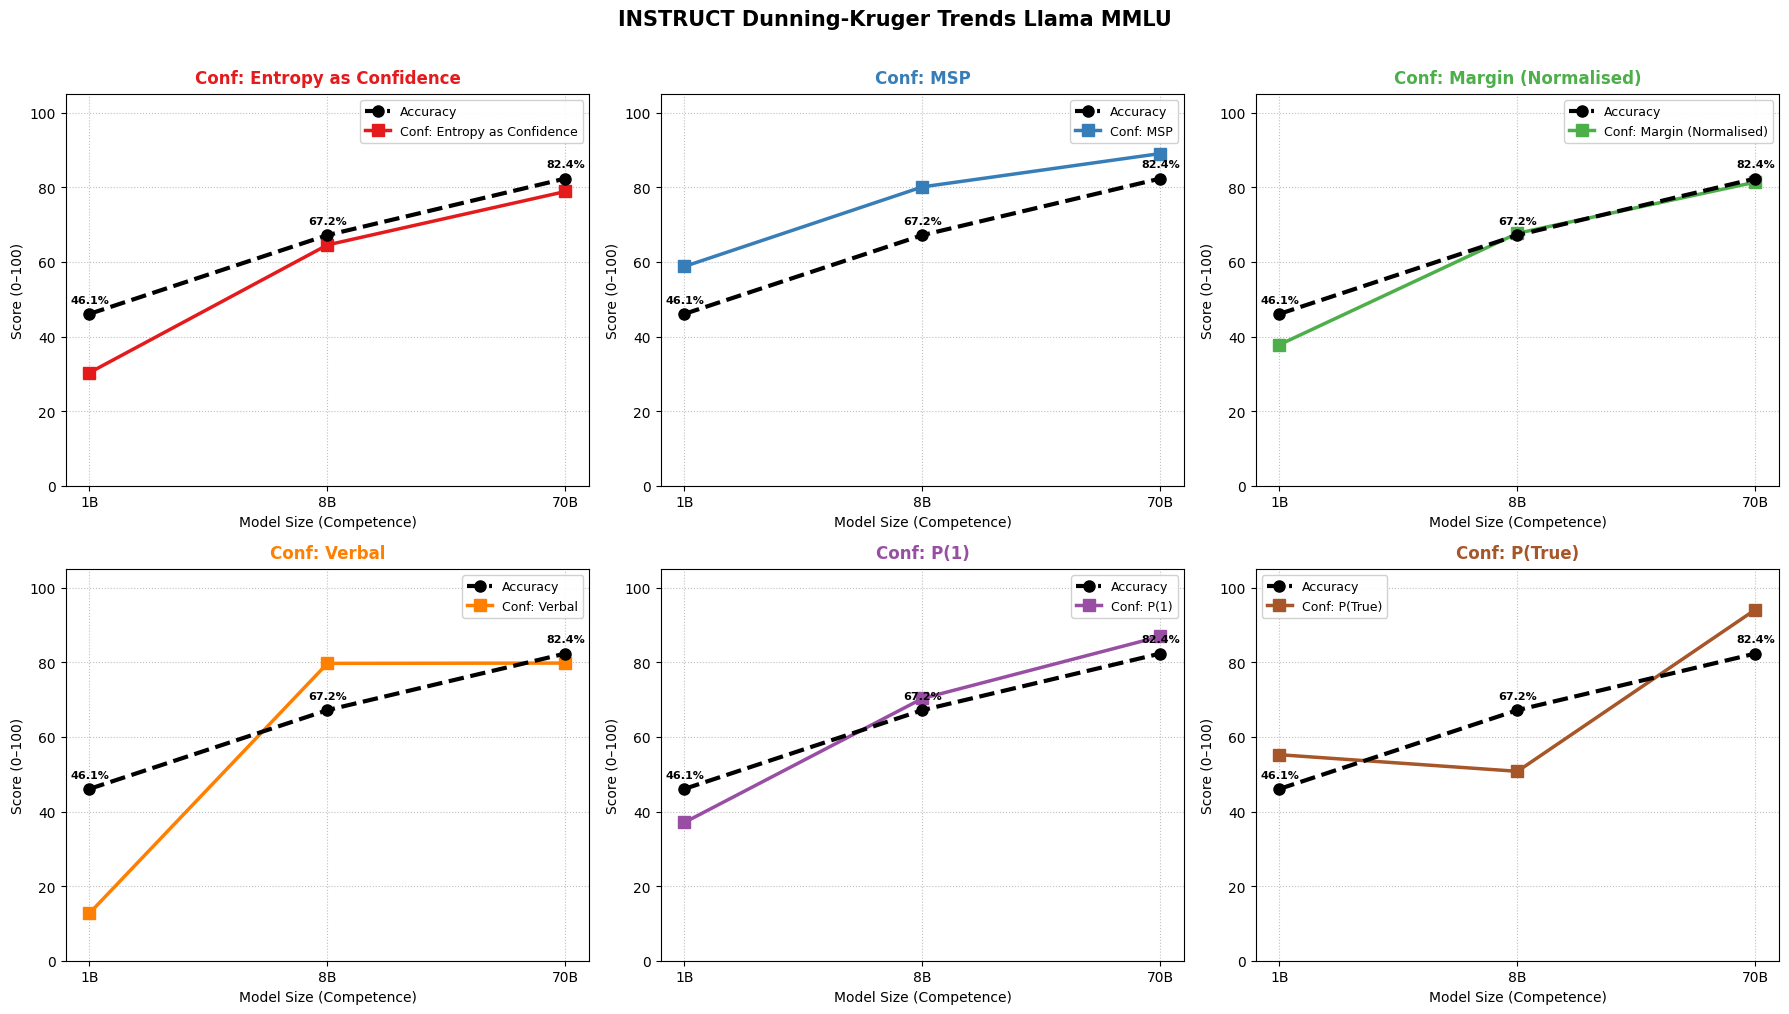

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
#  SUBPLOT LINE CHARTS — Each confidence metric in its own panel
# ═══════════════════════════════════════════════════════════════════════════

n_metrics = len(CONF_METRICS)
n_cols = 3
n_rows = (n_metrics + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5), sharey=False)
axes = axes.flatten()  # easier to iterate

for i, (col, scale) in enumerate(CONF_METRICS.items()):
    ax = axes[i]
    lbl = CONF_LABELS[col]

    # accuracy — thick black dashed (same on every subplot for reference)
    ax.plot(MODEL_SIZES, accuracy_scores,
            marker='o', linewidth=3, markersize=8,
            label='Accuracy', color='black', linestyle='--', zorder=5)

    # annotate accuracy
    for j, v in enumerate(accuracy_scores):
        ax.annotate(f'{v:.1f}%', xy=(j, v), xytext=(0, 8),
                    textcoords='offset points', ha='center',
                    fontsize=8, fontweight='bold', color='black')

    # confidence metric
    ax.plot(MODEL_SIZES, confidence_scores[col],
            marker='s', linewidth=2.5, markersize=8,
            label=f'Conf: {lbl}', color=CONF_COLORS[col])

    ax.set_title(f'Conf: {lbl}', fontsize=12, fontweight='bold',
                 color=CONF_COLORS[col], pad=8)
    ax.set_ylabel('Score (0–100)', fontsize=10)
    ax.set_xlabel('Model Size (Competence)', fontsize=10)
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g'))
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(True, linestyle=':', alpha=0.5, color='grey')
    ax.legend(fontsize=9, framealpha=0.9)

# hide any unused subplot panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('INSTRUCT Dunning-Kruger Trends Llama MMLU',
             fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout()

plt.savefig(
    'llama_mmlu_instruct_1.png', 
    dpi=600,                  # High resolution for print/PDF dissertations (600 is also an option)
    bbox_inches='tight',      # Automatically crops unnecessary white space and ensures text isn't cut off
    facecolor='white',        # Ensures the saved image background is solid white, not gray or transparent
    edgecolor='none'
)
plt.show()

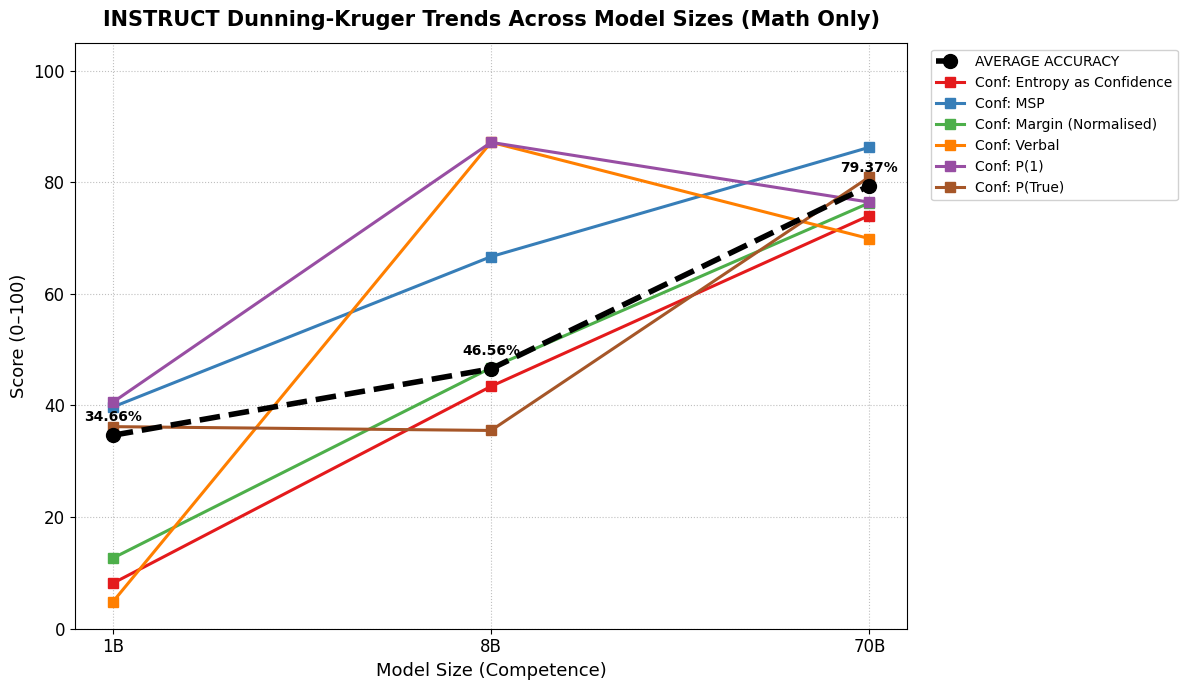

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
#  COMBINED LINE CHART — Inter Dunning-Kruger Curve (MATH CATEGORIES ONLY)
#  Black dashed = Accuracy  |  Coloured lines = each confidence metric
# ═══════════════════════════════════════════════════════════════════════════

# ── Recompute scores for math categories only ─────────────────────────────
MATH_CATEGORIES = {
    'abstract_algebra',
    'college_mathematics',
    'elementary_mathematics',
    'high_school_mathematics',
}

MATH_CATEGORIES = {
    'elementary_mathematics',
}

accuracy_scores   = []
confidence_scores = {col: [] for col in CONF_METRICS}

for name in MODEL_SIZES:
    df_math = dfs[name][dfs[name]['Category'].isin(MATH_CATEGORIES)]
    accuracy_scores.append(df_math['is_correct'].astype(int).mean() * 100)
    for col, scale in CONF_METRICS.items():
        confidence_scores[col].append(df_math[col].mean() * scale)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# accuracy — thick black dashed
ax.plot(MODEL_SIZES, accuracy_scores,
        marker='o', linewidth=4, markersize=10,
        label='AVERAGE ACCURACY', color='black', linestyle='--', zorder=5)

# annotate accuracy values above each point
for i, v in enumerate(accuracy_scores):
    ax.annotate(f'{v:.2f}%', xy=(i, v), xytext=(0, 10),
                textcoords='offset points', ha='center',
                fontsize=10, fontweight='bold', color='black')

# confidence metrics — coloured
for col in CONF_METRICS:
    lbl = CONF_LABELS[col]
    ax.plot(MODEL_SIZES, confidence_scores[col],
            marker='s', linewidth=2.2, markersize=7,
            label=f'Conf: {lbl}', color=CONF_COLORS[col])

ax.set_title('INSTRUCT Dunning-Kruger Trends Across Model Sizes (Math Only)',
             fontsize=15, fontweight='bold', pad=12)
ax.set_ylabel('Score (0–100)', fontsize=13)
ax.set_xlabel('Model Size (Competence)', fontsize=13)
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g'))
ax.tick_params(axis='both', labelsize=12)
ax.grid(True, linestyle=':', alpha=0.5, color='grey')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left',
          fontsize=10, framealpha=0.9, edgecolor='#cccccc')
fig.tight_layout()
plt.show()

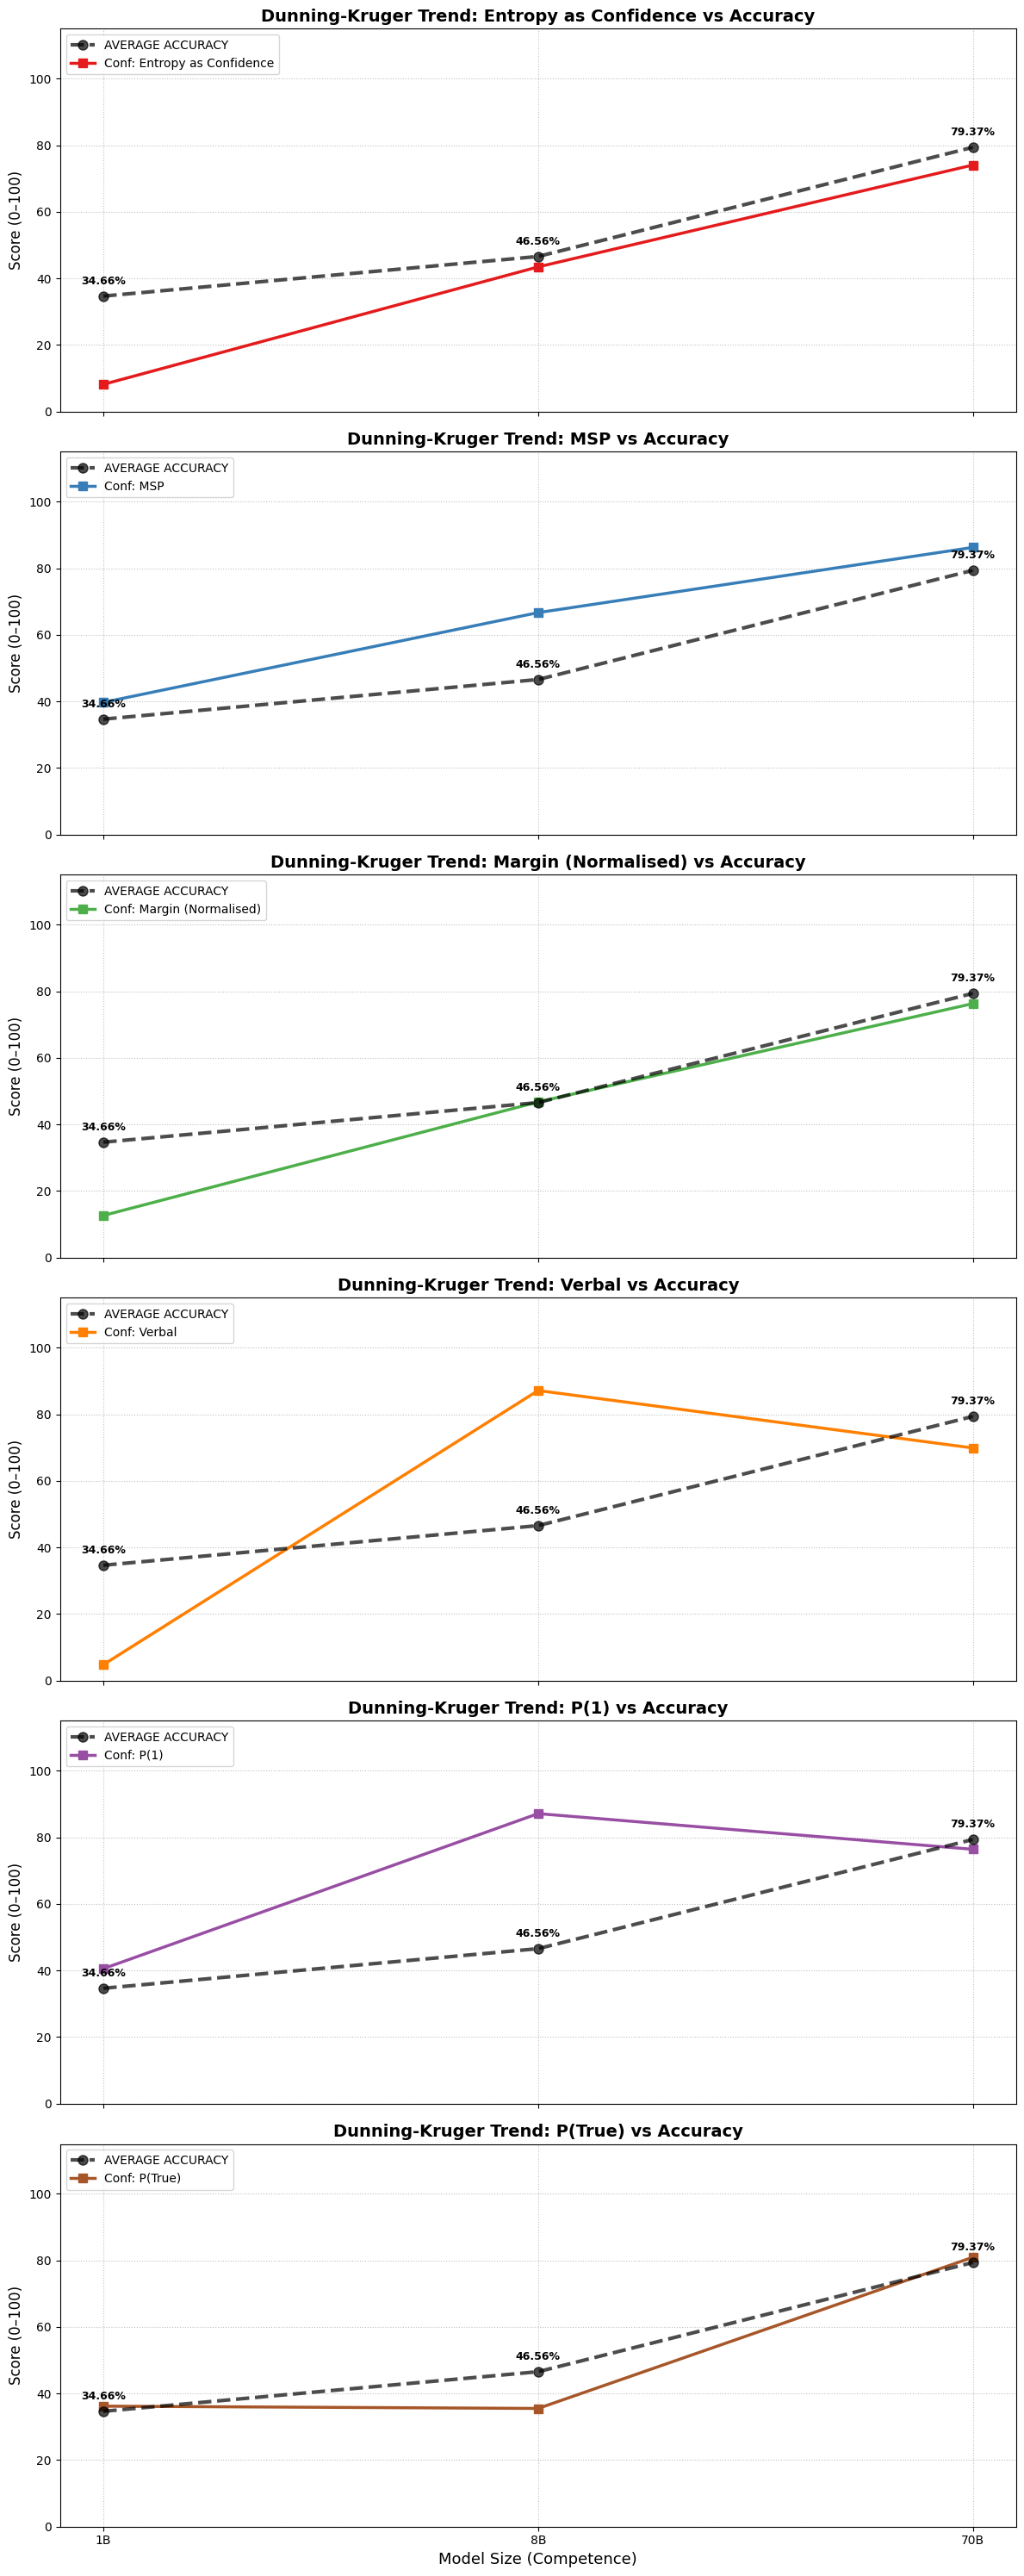

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Determine the number of metrics to create the grid
num_metrics = len(CONF_METRICS)
fig, axes = plt.subplots(num_metrics, 1, figsize=(12, 5 * num_metrics), sharex=True)

# If there is only one metric, axes might not be a list; wrap it to be safe
if num_metrics == 1:
    axes = [axes]

for i, col in enumerate(CONF_METRICS):
    ax = axes[i]
    lbl = CONF_LABELS[col]
    color = CONF_COLORS[col]
    
    # 1. Plot Accuracy (Black dashed) as the baseline for every subplot
    ax.plot(MODEL_SIZES, accuracy_scores,
            marker='o', linewidth=3, markersize=8,
            label='AVERAGE ACCURACY', color='black', linestyle='--', zorder=5, alpha=0.7)

    # Annotate accuracy values
    for idx, v in enumerate(accuracy_scores):
        ax.annotate(f'{v:.2f}%', xy=(MODEL_SIZES[idx], v), xytext=(0, 10),
                    textcoords='offset points', ha='center',
                    fontsize=9, fontweight='bold', color='black')

    # 2. Plot the specific Confidence Metric for this subplot
    ax.plot(MODEL_SIZES, confidence_scores[col],
            marker='s', linewidth=2.5, markersize=7,
            label=f'Conf: {lbl}', color=color)

    # 3. Formatting each subplot
    ax.set_title(f'Dunning-Kruger Trend: {lbl} vs Accuracy', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score (0–100)', fontsize=12)
    ax.set_ylim(0, 115) # Increased slightly to fit annotations
    ax.grid(True, linestyle=':', alpha=0.5, color='grey')
    ax.legend(loc='upper left', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g'))

# Final global formatting
axes[-1].set_xlabel('Model Size (Competence)', fontsize=13)
plt.tight_layout()
plt.show()

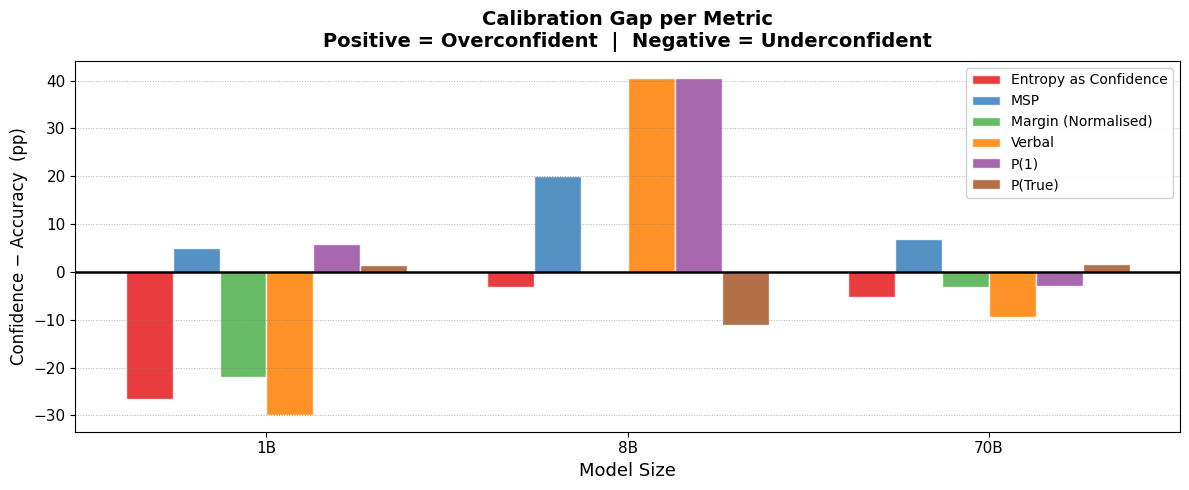

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
#  CALIBRATION GAP — (confidence − accuracy)
#  Positive = overconfident, Negative = underconfident
# ═══════════════════════════════════════════════════════════════════════════

n_conf  = len(CONF_METRICS)
bar_w   = 0.13
offsets = np.linspace(-(n_conf - 1) / 2 * bar_w, (n_conf - 1) / 2 * bar_w, n_conf)
x_pos   = np.arange(len(MODEL_SIZES))

fig, ax = plt.subplots(figsize=(12, 5))

for i, col in enumerate(CONF_METRICS):
    #for each confidence metric
    lbl  = CONF_LABELS[col]
    #takes the confidence score and subtracts it from the accuracy
    #that way you see the gap: positive value means over-confidence
    ##Negative value means under-confidence
    ##0 means calibrated
    gaps = [confidence_scores[col][j] - accuracy_scores[j]
            for j in range(len(MODEL_SIZES))]
    ax.bar(x_pos + offsets[i], gaps, bar_w,
           color=CONF_COLORS[col], alpha=0.85, label=lbl, edgecolor='white')

ax.axhline(0, color='black', lw=1.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(MODEL_SIZES, fontsize=12)
ax.set_xlabel('Model Size', fontsize=13)
ax.set_ylabel('Confidence − Accuracy  (pp)', fontsize=12)
ax.set_title('Calibration Gap per Metric\nPositive = Overconfident  |  Negative = Underconfident',
             fontsize=14, fontweight='bold', pad=10)
ax.tick_params(axis='both', labelsize=11)
ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.6, color='grey')
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
fig.tight_layout()
plt.show()


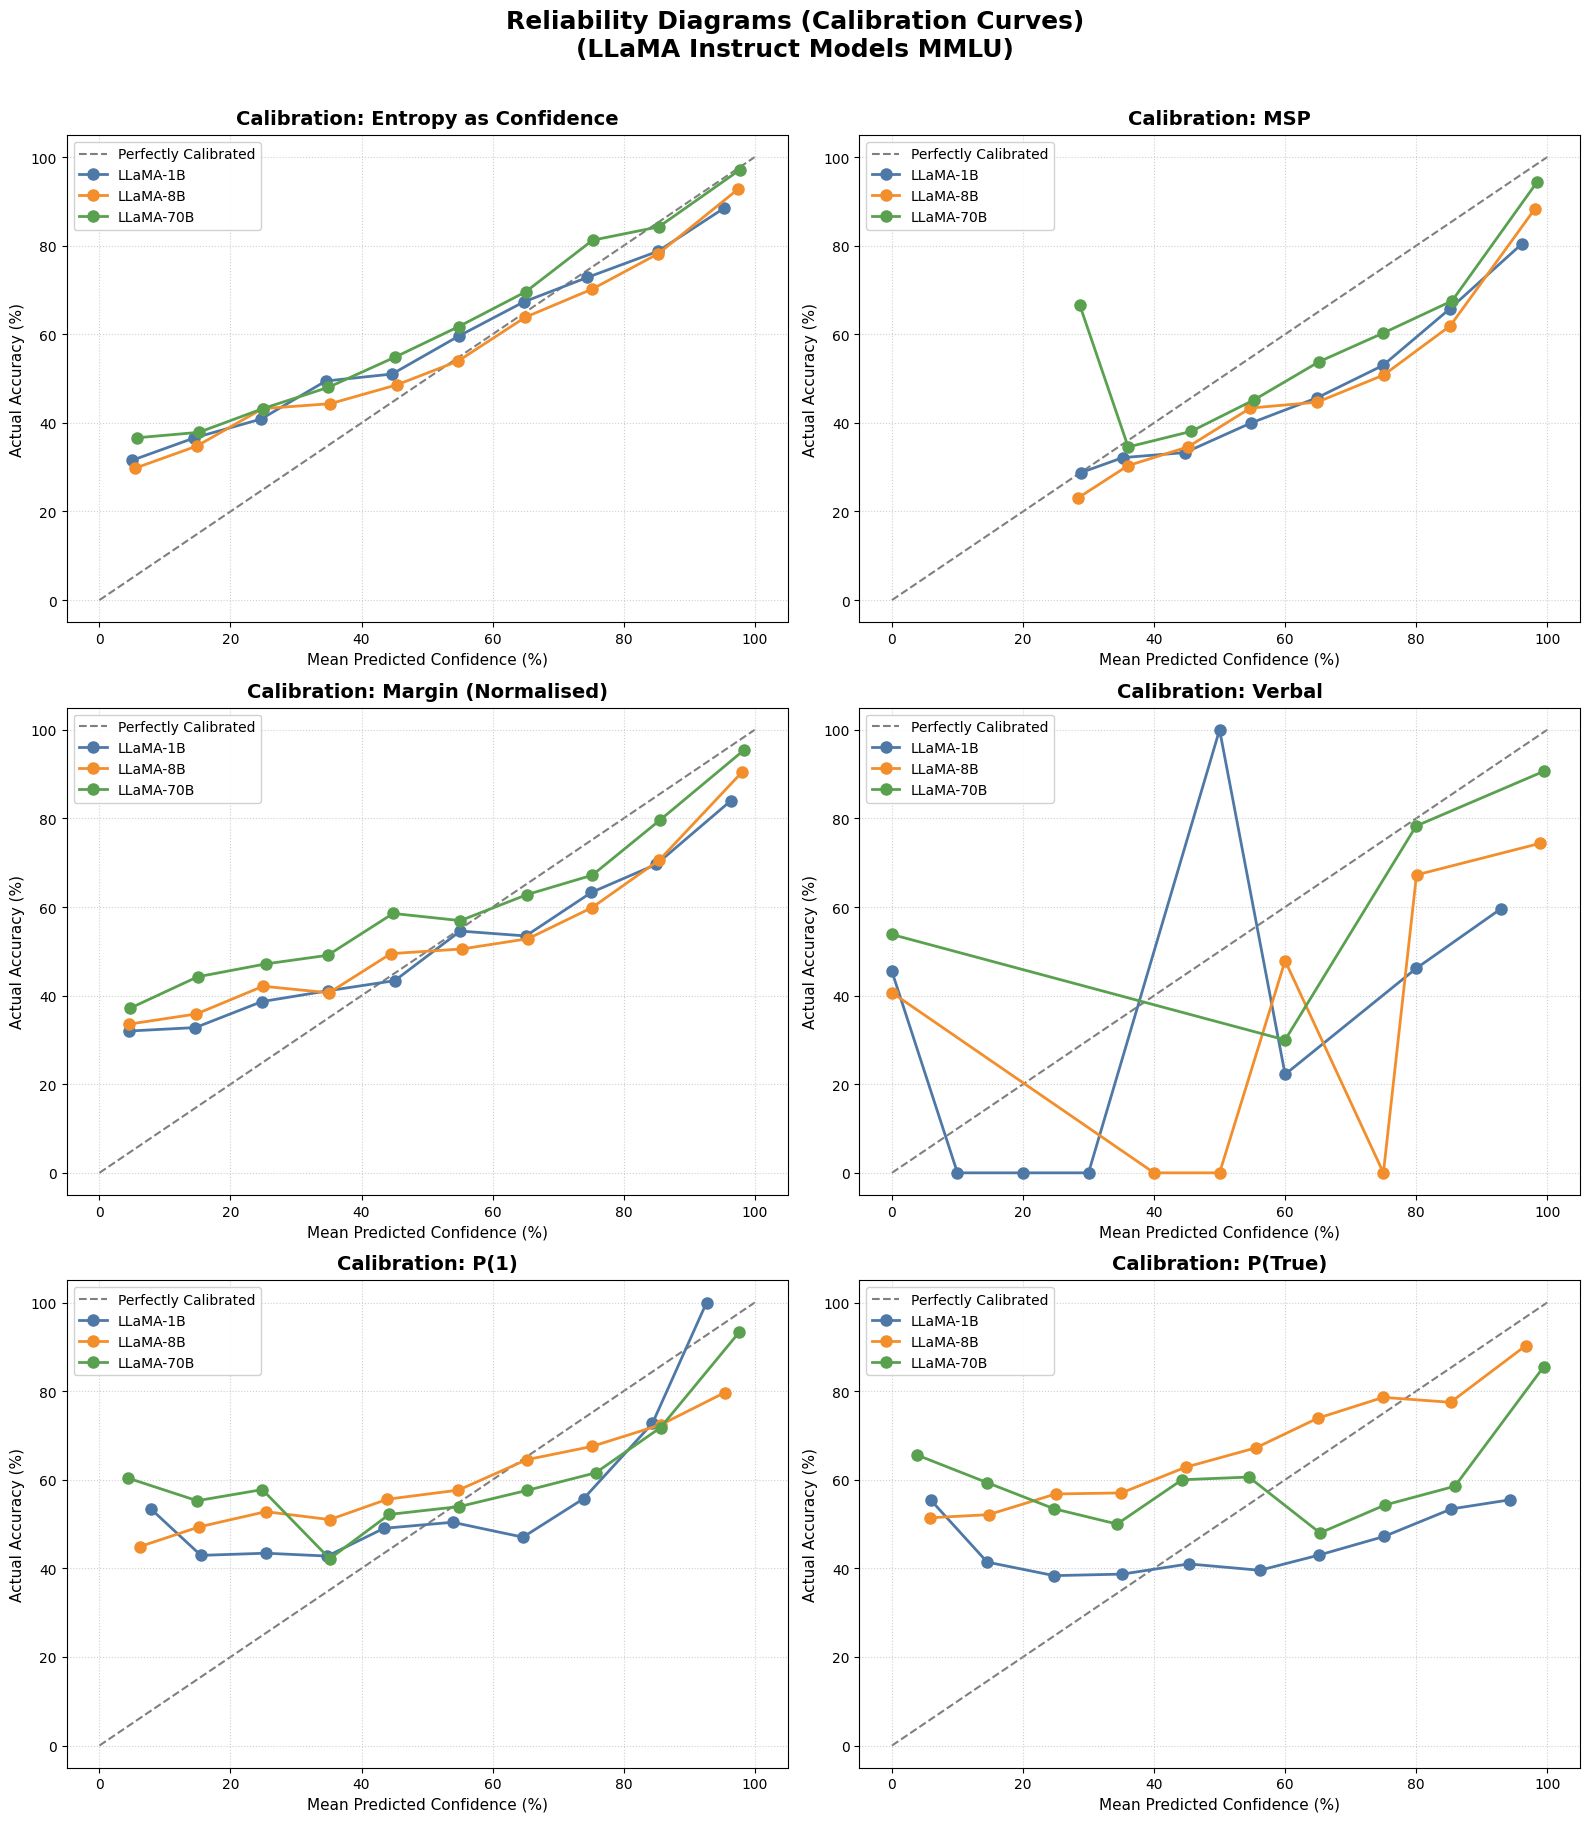

In [15]:
# ═══════════════════════════════════════════════════════════════════════════
#  RELIABILITY DIAGRAMS (Calibration Curves) — 2x3 grid, one per metric
#  Rows already filtered (no blank letter_llm_outputted_detected) via dfs
#  Perfect calibration = black dashed diagonal
# ═══════════════════════════════════════════════════════════════════════════

MODEL_LINE_COLORS = {'1B': '#4e79a7', '8B': '#f28e2b', '70B': '#59a14f'}

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, (col, scale) in enumerate(CONF_METRICS.items()):
    #for each confidence metric
    ax = axes[i]
    lbl = CONF_LABELS[col]

    # Perfect calibration diagonal
    ax.plot([0, 100], [0, 100], color='black', linestyle='--',
            alpha=0.5, label='Perfectly Calibrated', zorder=1)

    for size in MODEL_SIZES:
        #for each model we get the dataframe
        df = dfs[size]   # already excludes blank-letter rows

        #drop rows that are empty
        temp_df = df.dropna(subset=[col]).copy()
        #get the confidence column and all it's rows for that specific confidence metric (loops around)
        conf_values = pd.to_numeric(temp_df[col], errors='coerce') * scale #scales it correctly
        #gets the accuracy value (*100 to make percentage)
        acc_values  = temp_df['is_correct'].astype(int) * 100

        # 10 equal-width bins over 0–100
       #creates 10 equal bins 
        bins        = np.linspace(0, 100, 11)
        #takes every single row/confidence entry for that confidence metric and fits it into the bin
        bin_indices = np.digitize(conf_values, bins) - 1 #-1 just because python counting starts from 0
        bin_indices = bin_indices.clip(0, 9)   # keep 100.0 in last bin/ fixes the extreme number values

        bin_confs, bin_accs = [], []
        for b in range(10):
            #go through each bin
            mask = (bin_indices == b)
            if mask.any():#only calcualtes the average if the bin has data inside it (if for a range there was no numbers, then the average won't be created/that point will not exist)
                #get the average value and stick it into an list (so will have for each model one list with 10 average values for each bin)
                bin_confs.append(conf_values[mask].mean())
                bin_accs.append(acc_values[mask].mean())

        ax.plot(bin_confs, bin_accs, #linear interpolation/ draw's a straight line between the points
                #this just plots those bins, each bin is a dot/point on the line
                marker='o', linewidth=2, markersize=8,
                color=MODEL_LINE_COLORS[size], label=f'LLaMA-{size}')

    ax.set_title(f'Calibration: {lbl}', fontsize=14, fontweight='bold', pad=8)
    ax.set_xlabel('Mean Predicted Confidence (%)', fontsize=11)
    ax.set_ylabel('Actual Accuracy (%)', fontsize=11)
    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=10, framealpha=0.9)

fig.suptitle('Reliability Diagrams (Calibration Curves)\n(LLaMA Instruct Models MMLU)',
             fontsize=18, fontweight='bold', y=1.01)
plt.savefig(
    'llama_mmlu_instruct_3.png', 
    dpi=300,                  # High resolution for print/PDF dissertations (600 is also an option)
    bbox_inches='tight',      # Automatically crops unnecessary white space and ensures text isn't cut off
    facecolor='white',        # Ensures the saved image background is solid white, not gray or transparent
    edgecolor='none'
)
fig.tight_layout()
plt.show()

In [16]:
n_bins = 10

for col, scale in CONF_METRICS.items():

    temp_df = df.dropna(subset=[col]).copy()

    conf_values = pd.to_numeric(temp_df[col], errors='coerce') * scale
    acc_values  = temp_df['is_correct'].astype(int)

    temp_df['bin'] = pd.cut(
        conf_values,
        bins=np.linspace(0,100,n_bins +1),
        include_lowest=True
    )

    bin_summary = (
        temp_df
        .groupby('bin', observed=False)
        .agg(
            count=('is_correct', 'size'),
            mean_confidence=(col, 'mean'),
            mean_accuracy=('is_correct', lambda x: x.mean() * 100),
            min_confidence=(col, 'min'),
            max_confidence=(col, 'max')
        )
    )

    print("\n==============================")
    print(f"Metric: {col}")
    print("==============================")
    print(bin_summary.to_string())


Metric: Entropy_as_confidence
                count  mean_confidence  mean_accuracy  min_confidence  max_confidence
bin                                                                                  
(-0.001, 10.0]    101         0.056777      36.633663        0.001100        0.099759
(10.0, 20.0]      169         0.151655      37.869822        0.100737        0.199354
(20.0, 30.0]      236         0.249380      43.220339        0.200219        0.299708
(30.0, 40.0]      254         0.349397      48.031496        0.300107        0.399855
(40.0, 50.0]      359         0.451574      54.874652        0.400169        0.499821
(50.0, 60.0]      345         0.548310      61.739130        0.500182        0.599804
(60.0, 70.0]      355         0.650411      69.577465        0.600077        0.699555
(70.0, 80.0]      389         0.752585      81.233933        0.700437        0.799788
(80.0, 90.0]      565         0.853568      84.247788        0.800115        0.899904
(90.0, 100.0]    3460  

In [14]:
# ===== PRINT FIXED-WIDTH BIN SUMMARY =====

n_bins = 10

# Create fixed-width bins (0–100)
temp_df['bin'] = pd.cut(
    conf_values,
    bins=np.linspace(0, 100, n_bins + 1),
    include_lowest=True
)

# Group and summarize
bin_summary = (
    temp_df
    .groupby('bin')
    .agg(
        count=('is_correct', 'size'),
        mean_confidence=(col, 'mean'),
        mean_accuracy=('is_correct', lambda x: x.mean() * 100),
        min_confidence=(col, 'min'),
        max_confidence=(col, 'max')
    )
    .reset_index()
)

print("\n==============================")
print(f"Model: {size}")
print(f"Metric: {lbl}")
print("==============================")

print(bin_summary.to_string(index=False))


Model: 70B
Metric: P(True)
           bin  count  mean_confidence  mean_accuracy  min_confidence  max_confidence
(-0.001, 10.0]     90         0.038767      65.555556        0.000804        0.095349
  (10.0, 20.0]     64         0.144911      59.375000        0.106691        0.182426
  (20.0, 30.0]     58         0.247479      53.448276        0.201813        0.294215
  (30.0, 40.0]     36         0.343562      50.000000        0.320821        0.377541
  (40.0, 50.0]     60         0.457076      60.000000        0.407333        0.500000
  (50.0, 60.0]     51         0.557842      60.784314        0.531209        0.592667
  (60.0, 70.0]     50         0.653238      48.000000        0.622459        0.679179
  (70.0, 80.0]    116         0.752638      54.310345        0.705785        0.798187
  (80.0, 90.0]    164         0.859096      58.536585        0.817574        0.893309
 (90.0, 100.0]   5544         0.994373      85.461760        0.904651        0.999999


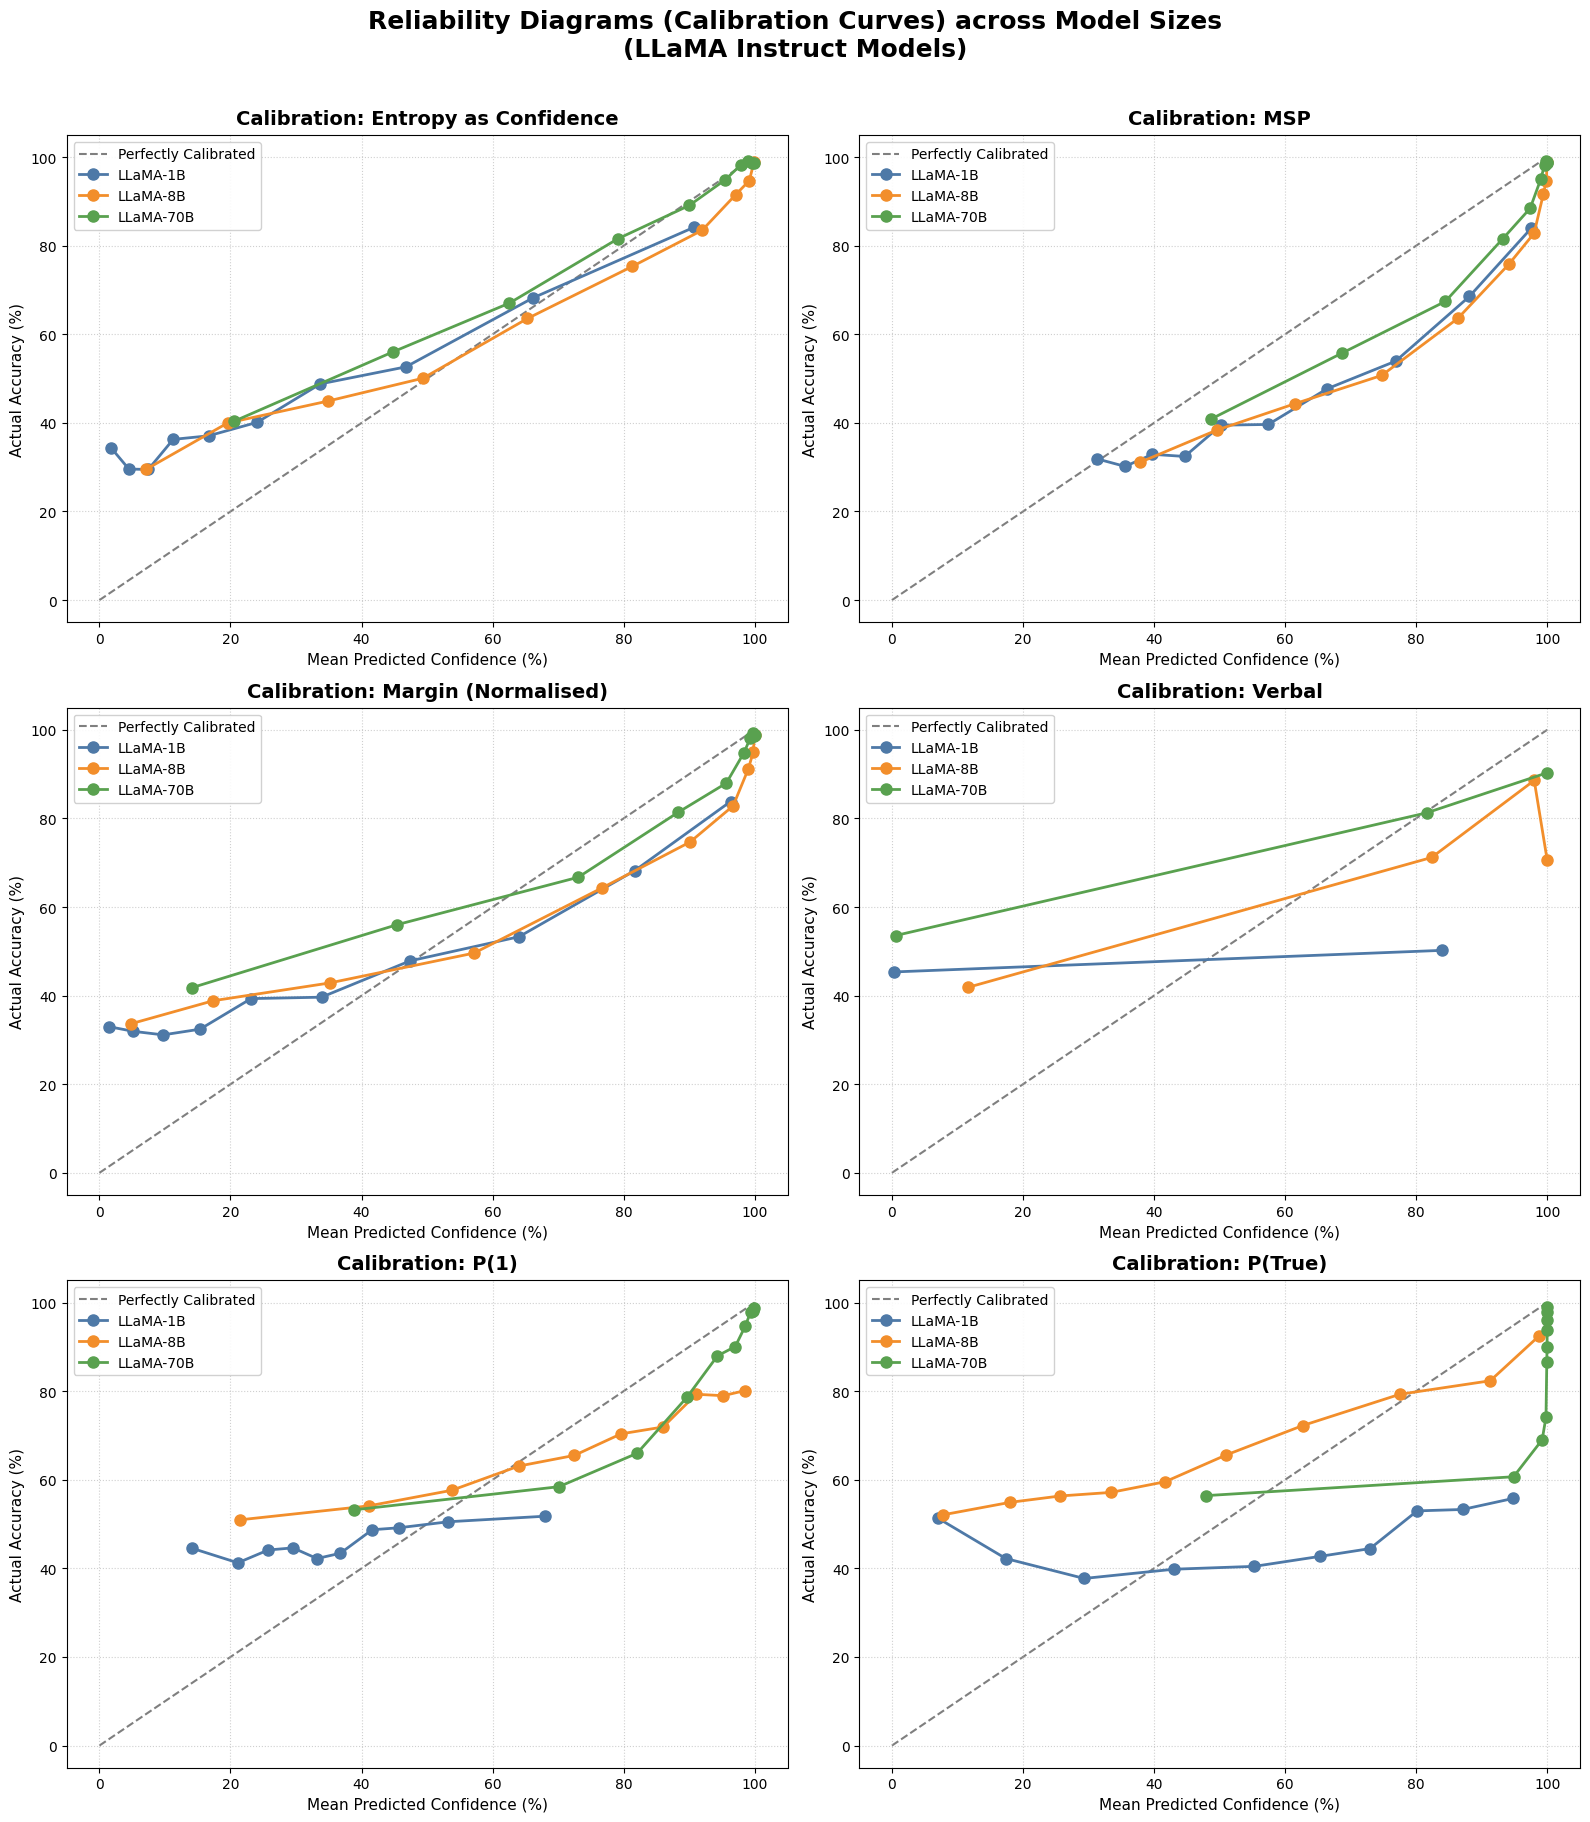

In [15]:
# ═══════════════════════════════════════════════════════════════════════════
#  RELIABILITY DIAGRAMS (Calibration Curves) — 2x3 grid, one per metric
#  Rows already filtered (no blank letter_llm_outputted_detected) via dfs
#  Perfect calibration = black dashed diagonal
# ═══════════════════════════════════════════════════════════════════════════

#######NOT FIXED BINNING ############

MODEL_LINE_COLORS = {'1B': '#4e79a7', '8B': '#f28e2b', '70B': '#59a14f'}

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, (col, scale) in enumerate(CONF_METRICS.items()):
    #for each confidence metric
    ax = axes[i]
    lbl = CONF_LABELS[col]

    # Perfect calibration diagonal
    ax.plot([0, 100], [0, 100], color='black', linestyle='--',
            alpha=0.5, label='Perfectly Calibrated', zorder=1)

    for size in MODEL_SIZES:
        #for each model we get the dataframe
        df = dfs[size]   # already excludes blank-letter rows

        #drop rows that are empty
        temp_df = df.dropna(subset=[col]).copy()
        #get the confidence column and all it's rows for that specific confidence metric (loops around)
        conf_values = pd.to_numeric(temp_df[col], errors='coerce') * scale #scales it correctly
        #gets the accuracy value (*100 to make percentage)
        acc_values  = temp_df['is_correct'].astype(int) * 100

        # 10 equal-width bins over 0–100
       #creates 10 equal bins 
        # Create 10 bins with roughly equal number of samples
        n_bins = 10

        # Compute quantile-based bin edges
        quantiles = np.linspace(0, 1, n_bins + 1)
        bins = np.quantile(conf_values, quantiles)

        # Assign each value to a bin
        bin_indices = np.digitize(conf_values, bins) - 1
        bin_indices = bin_indices.clip(0, n_bins - 1)

        bin_confs, bin_accs = [], []
        for b in range(10):
            #go through each bin
            mask = (bin_indices == b)
            if mask.any():#only calcualtes the average if the bin has data inside it (if for a range there was no numbers, then the average won't be created/that point will not exist)
                #get the average value and stick it into an list (so will have for each model one list with 10 average values for each bin)
                bin_confs.append(conf_values[mask].mean())
                bin_accs.append(acc_values[mask].mean())

        ax.plot(bin_confs, bin_accs, #linear interpolation/ draw's a straight line between the points
                #this just plots those bins, each bin is a dot/point on the line
                marker='o', linewidth=2, markersize=8,
                color=MODEL_LINE_COLORS[size], label=f'LLaMA-{size}')

    ax.set_title(f'Calibration: {lbl}', fontsize=14, fontweight='bold', pad=8)
    ax.set_xlabel('Mean Predicted Confidence (%)', fontsize=11)
    ax.set_ylabel('Actual Accuracy (%)', fontsize=11)
    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=10, framealpha=0.9)

fig.suptitle('Reliability Diagrams (Calibration Curves) across Model Sizes\n(LLaMA Instruct Models)',
             fontsize=18, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

In [16]:
n_bins = 10

# Create equal-count bins
temp_df['bin'] = pd.qcut(
    conf_values,
    q=n_bins,
    duplicates='drop'
)

# Group by bin and compute summary statistics
bin_summary = (
    temp_df
    .groupby('bin')
    .agg(
        count=('is_correct', 'size'),
        mean_confidence=(col, 'mean'),
        mean_accuracy=('is_correct', lambda x: x.mean() * 100),
        min_confidence=(col, 'min'),
        max_confidence=(col, 'max')
    )
)

print("\nBin summary:")
print(bin_summary)


Bin summary:
                  count  mean_confidence  mean_accuracy  min_confidence  \
bin                                                                       
(0.0794, 86.704]    624         0.478684      56.410256        0.000804   
(86.704, 98.409]    623         0.948611      60.674157        0.867036   
(98.409, 99.641]    623         0.992277      69.020867        0.984094   
(99.641, 99.897]    623         0.998117      74.157303        0.996406   
(99.897, 99.962]    624         0.999346      86.698718        0.998968   
(99.962, 99.984]    623         0.999746      89.887640        0.999620   
(99.984, 99.993]    623         0.999896      93.900482        0.999842   
(99.993, 99.997]    623         0.999955      95.987159        0.999934   
(99.997, 99.999]    624         0.999981      97.916667        0.999972   
(99.999, 100.0]     623         0.999994      99.036918        0.999989   

                  max_confidence  
bin                               
(0.0794, 86.704

In [17]:
n_bins = 10

for col, scale in CONF_METRICS.items():

    temp_df = df.dropna(subset=[col]).copy()

    conf_values = pd.to_numeric(temp_df[col], errors='coerce') * scale
    acc_values  = temp_df['is_correct'].astype(int)

    temp_df['bin'] = pd.qcut(
        conf_values,
        q=n_bins,
        duplicates='drop'
    )

    bin_summary = (
        temp_df
        .groupby('bin', observed=False)
        .agg(
            count=('is_correct', 'size'),
            mean_confidence=(col, 'mean'),
            mean_accuracy=('is_correct', lambda x: x.mean() * 100),
            min_confidence=(col, 'min'),
            max_confidence=(col, 'max')
        )
    )

    print("\n==============================")
    print(f"Metric: {col}")
    print("==============================")
    print(bin_summary.to_string())


Metric: Entropy_as_confidence
                  count  mean_confidence  mean_accuracy  min_confidence  max_confidence
bin                                                                                    
(0.109, 34.626]     624         0.205709      40.384615        0.001100        0.346111
(34.626, 53.512]    623         0.447831      56.019262        0.346839        0.534915
(53.512, 71.705]    624         0.626020      66.826923        0.535420        0.717046
(71.705, 85.528]    622         0.791505      81.832797        0.717287        0.855165
(85.528, 93.534]    624         0.900201      89.102564        0.855312        0.935338
(93.534, 96.923]    623         0.955019      94.863563        0.935414        0.969207
(96.923, 98.615]    623         0.978851      98.234350        0.969301        0.986148
(98.615, 99.378]    623         0.990214      99.036918        0.986148        0.993757
(99.378, 99.748]    623         0.995887      98.715891        0.993802        0.997477
(

In [30]:
# ═══════════════════════════════════════════════════════════════════════════
#  CALIBRATION METRICS — ECE, Brier Score, AUROC
#  + Confidence–Accuracy Correlation per metric per model
# ═══════════════════════════════════════════════════════════════════════════

from sklearn.metrics import brier_score_loss, roc_auc_score

# ── COMPUTE ──────────────────────────────────────────────────────────────────
#empty list that will become: results[confidence_metric][model_size][statistic]
results = {col: {size: {} for size in MODEL_SIZES} for col in CONF_METRICS}

for col, scale in CONF_METRICS.items():
    for size in MODEL_SIZES:
        df   = dfs[size]
        #removes missing values
        temp = df.dropna(subset=[col]).copy()

        ######## Creates the confidence bins and puts the confidence values inside those bisn 
        #converts values into numeric format 
        conf_raw  = pd.to_numeric(temp[col], errors='coerce')
        #ensures that all values are in the same range (0-1) by diving by 100 and clipping it from o to 1 
        conf_0_1  = ((conf_raw * scale) / 100).clip(0, 1)   # clip float noise to valid [0,1]
        #binary is_correct 1 =correct, 0 =incorrect
        correct   = temp['is_correct'].astype(int)

        # ── ECE (10 equal-width bins) ─────────────────────────────────────
        conf_pct    = conf_0_1 * 100 #makes into percentage 0-1 confidence score

        #Confidence values range from 0-100
        #11 numbers to create 10 even bins of that numebr range (bins start from 0 e.g. 0-10), so need 0,10,20...100
        bins        = np.linspace(0, 100, 11) 

        #assign every prediction to a bin (minus 1 because python counting starts from 0)
        bin_indices = np.digitize(conf_pct, bins) - 1
        #ensures bin assigned is valid 
        bin_indices = bin_indices.clip(0, 9)

        #####Calculates ECE
        ece = 0.0
        n   = len(temp)
        for b in range(10):
            #for each bin
            mask = (bin_indices == b)
            if mask.any():
                #bin accuracy 
                acc_b  = correct[mask].mean()
                #bin confidnece 
                conf_b = conf_0_1[mask].mean()
                #bin ECE value
                ece   += mask.sum() / n * abs(acc_b - conf_b)
        #ece *= 100   # express as percentage points

        # ── Brier Score ───────────────────────────────────────────────────
        brier = brier_score_loss(correct, conf_0_1)

        # ── AUROC ─────────────────────────────────────────────────────────
        try:
            auroc = roc_auc_score(correct, conf_0_1)
        except ValueError:
            auroc = float('nan')   # only one class present

        # ── Pearson Correlation (conf vs correct, row-level) ──────────────
        corr = conf_0_1.corr(correct.astype(float))

        results[col][size] = {
            'ECE (pp)':   ece,
            'Brier':      brier,
            'AUROC':      auroc,
            'Corr (r)':   corr,
        }

# ── PRINT TABLE ──────────────────────────────────────────────────────────────
print('\n' + '=' * 75)
print(f"{'METRIC':<26} {'MODEL':<6} {'ECE (pp)':>10} {'Brier':>8} {'AUROC':>8} {'Corr (r)':>10}")
print('-' * 75)

for col in CONF_METRICS:
    lbl = CONF_LABELS[col]
    for j, size in enumerate(MODEL_SIZES):
        r    = results[col][size]
        prefix = lbl if j == 0 else ''
        print(f"{prefix:<26} {size:<6} {r['ECE (pp)']:>10.2f} {r['Brier']:>8.4f} "
              f"{r['AUROC']:>8.4f} {r['Corr (r)']:>10.4f}")
    print('-' * 75)

print('=' * 75 + '\n')


METRIC                     MODEL    ECE (pp)    Brier    AUROC   Corr (r)
---------------------------------------------------------------------------
Entropy as Confidence      1B           0.17   0.2570   0.6785     0.3405
                           8B           0.08   0.1756   0.8094     0.5003
                           70B          0.04   0.1116   0.8602     0.5202
---------------------------------------------------------------------------
MSP                        1B           0.13   0.2401   0.6809     0.3315
                           8B           0.13   0.1863   0.8088     0.4804
                           70B          0.07   0.1134   0.8598     0.5039
---------------------------------------------------------------------------
Margin (Normalised)        1B           0.16   0.2515   0.6780     0.3316
                           8B           0.12   0.1860   0.8055     0.4780
                           70B          0.07   0.1176   0.8581     0.4994
-------------------------------

In [31]:
results

{'Entropy_as_confidence': {'1B': {'ECE (pp)': np.float64(0.17153873726281024),
   'Brier': 0.257002426794273,
   'AUROC': 0.678526226054158,
   'Corr (r)': np.float64(0.3404946386271703)},
  '8B': {'ECE (pp)': np.float64(0.0819519451656753),
   'Brier': 0.1755732248461362,
   'AUROC': 0.8094165890202067,
   'Corr (r)': np.float64(0.5003001870366389)},
  '70B': {'ECE (pp)': np.float64(0.04355601604876816),
   'Brier': 0.1116089645876098,
   'AUROC': 0.8601730226827307,
   'Corr (r)': np.float64(0.520225172707811)}},
 'Letter_MSP_confidence': {'1B': {'ECE (pp)': np.float64(0.12722295691338203),
   'Brier': 0.2400679131440025,
   'AUROC': 0.6808574515948143,
   'Corr (r)': np.float64(0.33152712485135155)},
  '8B': {'ECE (pp)': np.float64(0.1294159598472487),
   'Brier': 0.1863349038710538,
   'AUROC': 0.8088263591633331,
   'Corr (r)': np.float64(0.4804354493879179)},
  '70B': {'ECE (pp)': np.float64(0.06738314458989739),
   'Brier': 0.1134349249553255,
   'AUROC': 0.8597907294693303,
   

In [32]:
# ═══════════════════════════════════════════════════════════════════════════
#  AVERAGE METRICS ACROSS CONFIDENCE METRICS — one value per model size
# ═══════════════════════════════════════════════════════════════════════════

stat_keys = ['ECE (pp)', 'Brier', 'AUROC', 'Corr (r)']

print('\n' + '=' * 60)
print('AVERAGE ACROSS ALL CONFIDENCE METRICS (Llama Instruct)')
print('=' * 60)
print(f"{'MODEL':<6} {'ECE (pp)':>10} {'Brier':>8} {'AUROC':>8} {'Corr (r)':>10}")
print('-' * 60)

averaged = {}
for size in MODEL_SIZES:
    row = {}
    for stat in stat_keys:
        vals = [results[col][size][stat] for col in CONF_METRICS]
        row[stat] = np.nanmean(vals)
    averaged[size] = row
    print(f"{size:<6} {row['ECE (pp)']:>10.2f} {row['Brier']:>8.4f} "
          f"{row['AUROC']:>8.4f} {row['Corr (r)']:>10.4f}")

print('=' * 60 + '\n')


AVERAGE ACROSS ALL CONFIDENCE METRICS (Llama Instruct)
MODEL    ECE (pp)    Brier    AUROC   Corr (r)
------------------------------------------------------------
1B           0.21   0.2968   0.6047     0.1943
8B           0.14   0.2173   0.7193     0.3613
70B          0.09   0.1361   0.8145     0.4074



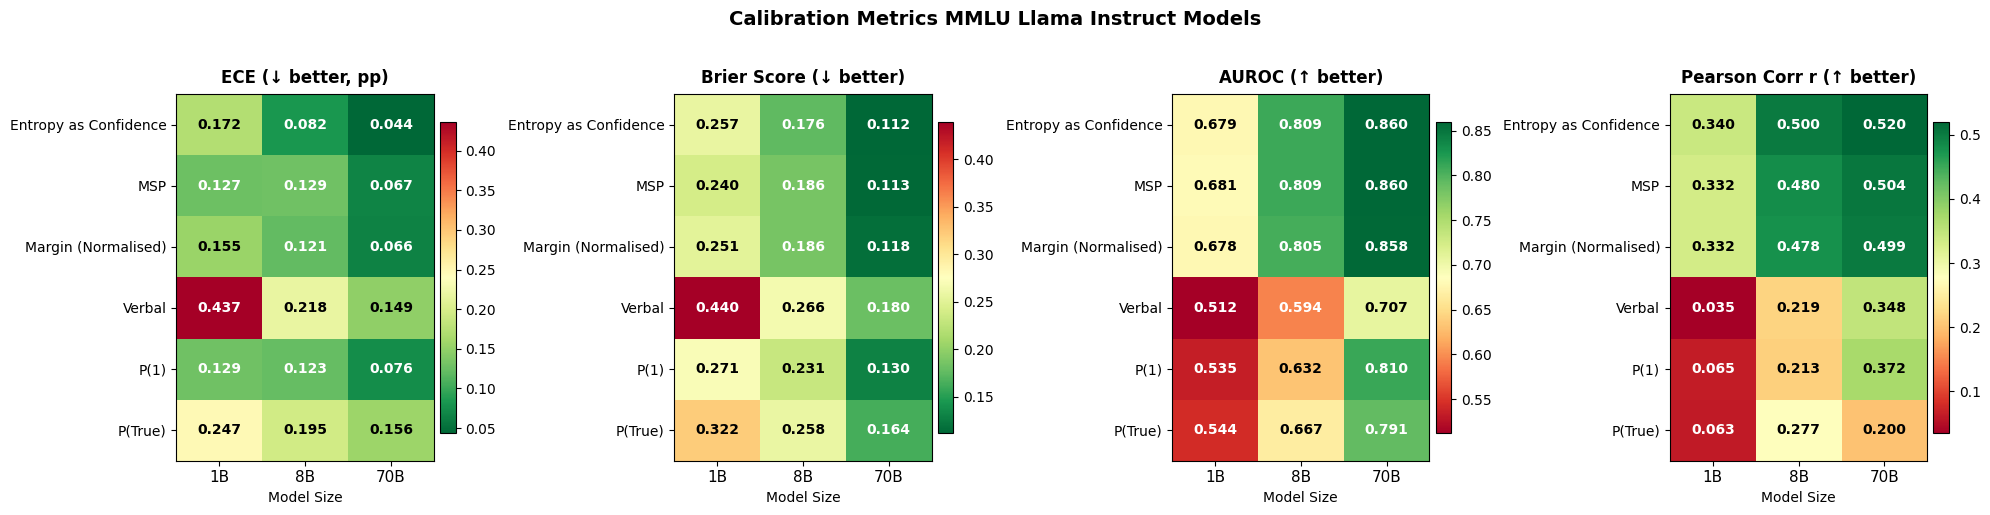

In [33]:
# ═══════════════════════════════════════════════════════════════════════════
#  METRIC COMPARISON HEATMAPS — ECE, Brier, AUROC, Correlation
#  Rows = confidence metrics, Columns = model sizes
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.colors as mcolors

stat_keys   = ['ECE (pp)', 'Brier', 'AUROC', 'Corr (r)']
stat_titles = ['ECE (↓ better, pp)', 'Brier Score (↓ better)', 
               'AUROC (↑ better)', 'Pearson Corr r (↑ better)']
# For ECE and Brier lower=better so we reverse the colormap
cmaps       = ['RdYlGn_r', 'RdYlGn_r', 'RdYlGn', 'RdYlGn']

labels_row  = [CONF_LABELS[col] for col in CONF_METRICS]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, stat, title, cmap in zip(axes, stat_keys, stat_titles, cmaps):
    matrix = np.array([[results[col][size][stat]
                        for size in MODEL_SIZES]
                       for col in CONF_METRICS])   # shape (6, 3)

    vmin, vmax = np.nanmin(matrix), np.nanmax(matrix)
    im = ax.imshow(matrix, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)

    # annotate cells
    for r in range(len(CONF_METRICS)):
        for c in range(len(MODEL_SIZES)):
            val = matrix[r, c]
            # pick text colour for legibility
            norm_val = (val - vmin) / (vmax - vmin + 1e-9)
            txt_col  = 'white' if (norm_val < 0.25 or norm_val > 0.75) else 'black'
            ax.text(c, r, f'{val:.3f}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color=txt_col)

    ax.set_xticks(range(len(MODEL_SIZES)))
    ax.set_xticklabels(MODEL_SIZES, fontsize=11)
    ax.set_yticks(range(len(CONF_METRICS)))
    ax.set_yticklabels(labels_row, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Model Size', fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)

fig.suptitle('Calibration Metrics MMLU Llama Instruct Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig(
    'llama_mmlu_instruct_4.png', 
    dpi=600,                  # High resolution for print/PDF dissertations (600 is also an option)
    bbox_inches='tight',      # Automatically crops unnecessary white space and ensures text isn't cut off
    facecolor='white',        # Ensures the saved image background is solid white, not gray or transparent
    edgecolor='none'
)
fig.tight_layout()
plt.show()


METRIC                     MODEL       ECE    Brier    AUROC   Corr (r)
-----------------------------------------------------------------------
Entropy as Confidence      1B         0.17     0.26     0.68       0.34
                           8B         0.08     0.18     0.81       0.50
                           70B        0.04     0.11     0.86       0.52
-----------------------------------------------------------------------
MSP                        1B         0.13     0.24     0.68       0.33
                           8B         0.13     0.19     0.81       0.48
                           70B        0.07     0.11     0.86       0.50
-----------------------------------------------------------------------
Margin (Normalised)        1B         0.16     0.25     0.68       0.33
                           8B         0.12     0.19     0.81       0.48
                           70B        0.07     0.12     0.86       0.50
---------------------------------------------------------------

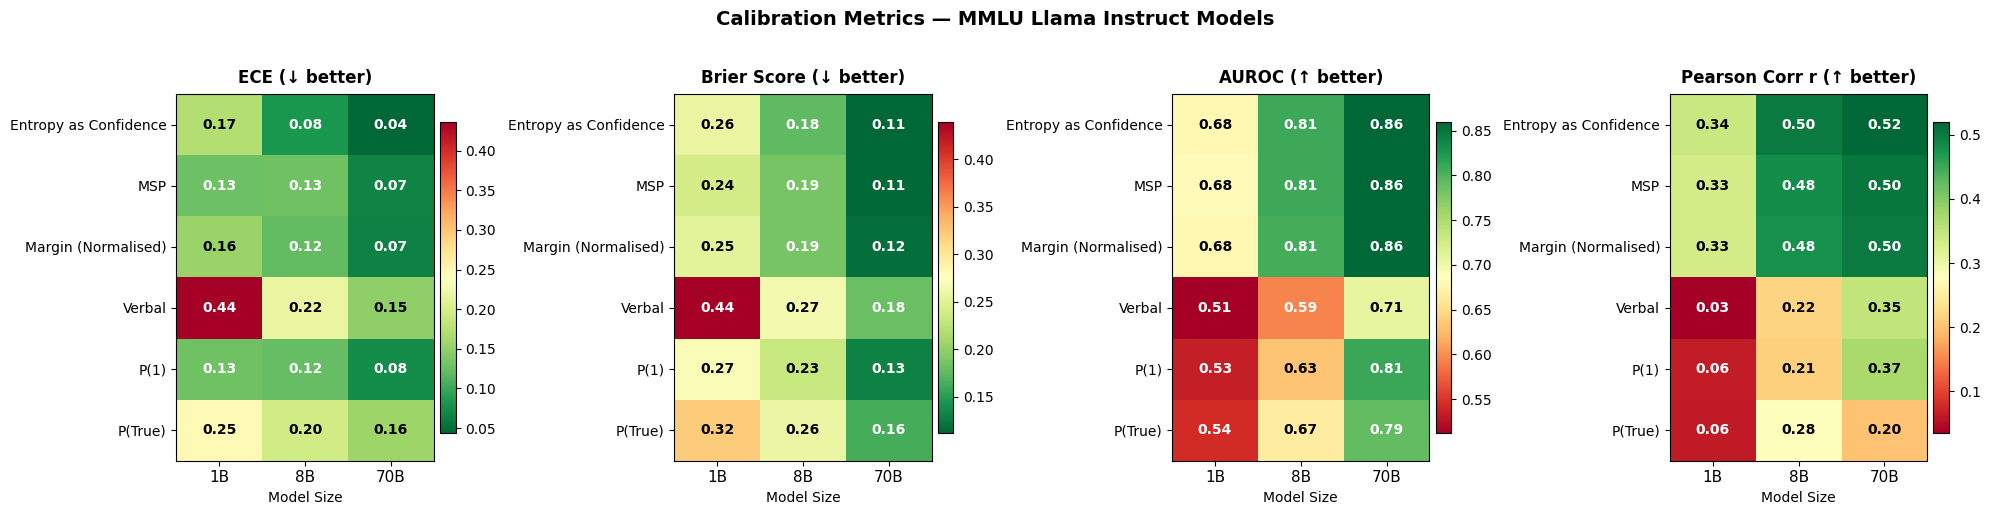

In [38]:
from sklearn.metrics import brier_score_loss, roc_auc_score
from netcal.metrics import ECE

# ── COMPUTE ──────────────────────────────────────────────────────────────────
results = {col: {size: {} for size in MODEL_SIZES} for col in CONF_METRICS}

for col, scale in CONF_METRICS.items():
    for size in MODEL_SIZES:
        df   = dfs[size]
        temp = df.dropna(subset=[col]).copy()

        conf_raw = pd.to_numeric(temp[col], errors='coerce')
        conf_0_1 = ((conf_raw * scale) / 100).clip(0, 1)
        correct  = temp['is_correct'].astype(int)

        # ── ECE via netcal (10 equal-width bins, matches manual calculation) ──
        ece = ECE(bins=10).measure(conf_0_1.values, correct.values)

        # ── Brier Score ───────────────────────────────────────────────────────
        brier = brier_score_loss(correct, conf_0_1)

        # ── AUROC ─────────────────────────────────────────────────────────────
        try:
            auroc = roc_auc_score(correct, conf_0_1)
        except ValueError:
            auroc = float('nan')

        # ── Pearson Correlation ────────────────────────────────────────────────
        corr = conf_0_1.corr(correct.astype(float))

        results[col][size] = {
            'ECE':      ece,
            'Brier':    brier,
            'AUROC':    auroc,
            'Corr (r)': corr,
        }

# ── PRINT TABLE ───────────────────────────────────────────────────────────────
print('\n' + '=' * 71)
print(f"{'METRIC':<26} {'MODEL':<6} {'ECE':>8} {'Brier':>8} {'AUROC':>8} {'Corr (r)':>10}")
print('-' * 71)

for col in CONF_METRICS:
    lbl = CONF_LABELS[col]
    for j, size in enumerate(MODEL_SIZES):
        r      = results[col][size]
        prefix = lbl if j == 0 else ''
        print(f"{prefix:<26} {size:<6} {r['ECE']:>8.2f} {r['Brier']:>8.2f} "
              f"{r['AUROC']:>8.2f} {r['Corr (r)']:>10.2f}")
    print('-' * 71)

print('=' * 71 + '\n')


# ═══════════════════════════════════════════════════════════════════════════
#  METRIC COMPARISON HEATMAPS — ECE, Brier, AUROC, Correlation
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.colors as mcolors

stat_keys   = ['ECE', 'Brier', 'AUROC', 'Corr (r)']
stat_titles = ['ECE (↓ better)', 'Brier Score (↓ better)',
               'AUROC (↑ better)', 'Pearson Corr r (↑ better)']
cmaps       = ['RdYlGn_r', 'RdYlGn_r', 'RdYlGn', 'RdYlGn']

labels_row = [CONF_LABELS[col] for col in CONF_METRICS]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, stat, title, cmap in zip(axes, stat_keys, stat_titles, cmaps):
    matrix = np.array([[results[col][size][stat]
                        for size in MODEL_SIZES]
                       for col in CONF_METRICS])   # shape (n_metrics, n_sizes)

    vmin, vmax = np.nanmin(matrix), np.nanmax(matrix)
    im = ax.imshow(matrix, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)

    for r in range(len(CONF_METRICS)):
        for c in range(len(MODEL_SIZES)):
            val      = matrix[r, c]
            norm_val = (val - vmin) / (vmax - vmin + 1e-9)
            txt_col  = 'white' if (norm_val < 0.25 or norm_val > 0.75) else 'black'
            ax.text(c, r, f'{val:.2f}',          # 2 d.p., leading zero always present
                    ha='center', va='center',
                    fontsize=10, fontweight='bold', color=txt_col)

    ax.set_xticks(range(len(MODEL_SIZES)))
    ax.set_xticklabels(MODEL_SIZES, fontsize=11)
    ax.set_yticks(range(len(CONF_METRICS)))
    ax.set_yticklabels(labels_row, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Model Size', fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)

fig.suptitle('Calibration Metrics — MMLU Llama Instruct Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig(
    'llama_mmlu_instruct_4.png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white',
    edgecolor='none'
)
fig.tight_layout()
plt.show()

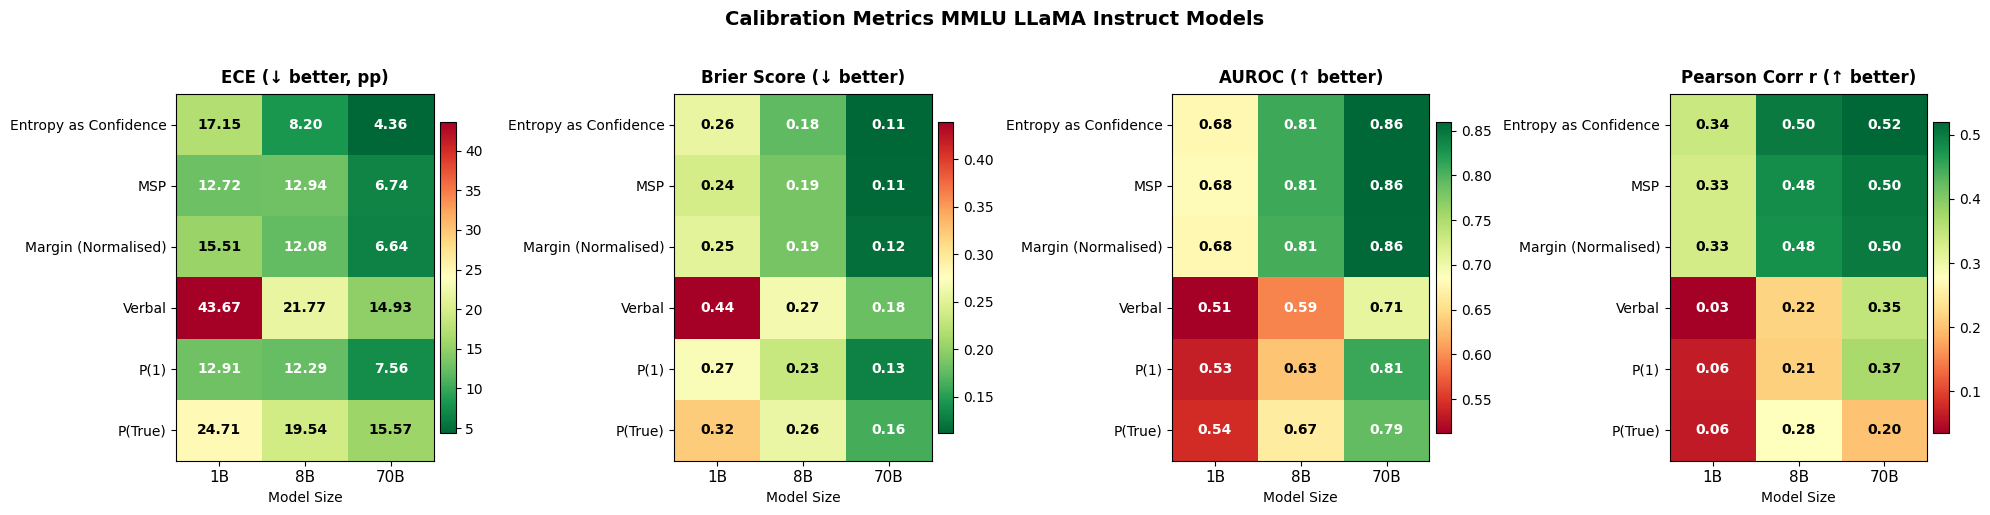

In [22]:
# ═══════════════════════════════════════════════════════════════════════════
#  METRIC COMPARISON HEATMAPS — ECE, Brier, AUROC, Correlation
#  Rows = confidence metrics, Columns = model sizes
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.colors as mcolors

stat_keys   = ['ECE (pp)', 'Brier', 'AUROC', 'Corr (r)']
stat_titles = ['ECE (↓ better, pp)', 'Brier Score (↓ better)', 
               'AUROC (↑ better)', 'Pearson Corr r (↑ better)']
cmaps       = ['RdYlGn_r', 'RdYlGn_r', 'RdYlGn', 'RdYlGn']

labels_row  = [CONF_LABELS[col] for col in CONF_METRICS]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, stat, title, cmap in zip(axes, stat_keys, stat_titles, cmaps):
    matrix = np.array([[results[col][size][stat]
                        for size in MODEL_SIZES]
                       for col in CONF_METRICS])

    vmin, vmax = np.nanmin(matrix), np.nanmax(matrix)
    im = ax.imshow(matrix, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)

    for r in range(len(CONF_METRICS)):
        for c in range(len(MODEL_SIZES)):
            val = matrix[r, c]
            norm_val = (val - vmin) / (vmax - vmin + 1e-9)
            txt_col  = 'white' if (norm_val < 0.25 or norm_val > 0.75) else 'black'
            ax.text(c, r, f'{val:.2f}', ha='center', va='center',      # ← .2f
                    fontsize=10, fontweight='bold', color=txt_col)

    ax.set_xticks(range(len(MODEL_SIZES)))
    ax.set_xticklabels(MODEL_SIZES, fontsize=11)
    ax.set_yticks(range(len(CONF_METRICS)))
    ax.set_yticklabels(labels_row, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Model Size', fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)

fig.suptitle('Calibration Metrics MMLU LLaMA Instruct Models',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
plt.savefig(
    'llama_mmlu_instruct_4.png', 
    dpi=600,                  # High resolution for print/PDF dissertations (600 is also an option)
    bbox_inches='tight',      # Automatically crops unnecessary white space and ensures text isn't cut off
    facecolor='white',        # Ensures the saved image background is solid white, not gray or transparent
    edgecolor='none'
)
plt.show()

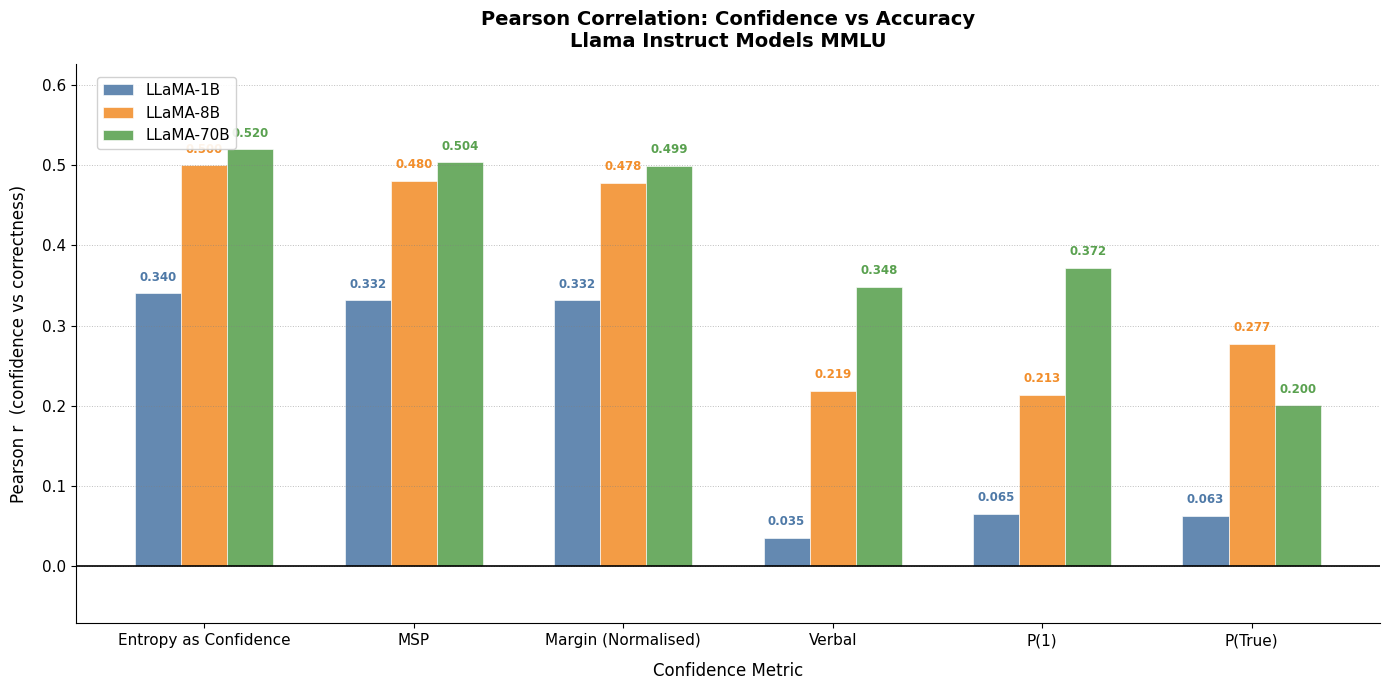

In [23]:
# ═══════════════════════════════════════════════════════════════════════════
#  CORRELATION PLOT — grouped bars, one group per metric, 3 bars per model
# ═══════════════════════════════════════════════════════════════════════════

MODEL_BAR_COLORS = {'1B': '#4e79a7', '8B': '#f28e2b', '70B': '#59a14f'}

n_metrics = len(CONF_METRICS)
bar_w     = 0.22
x         = np.arange(n_metrics)

fig, ax = plt.subplots(figsize=(14, 7))

for j, size in enumerate(MODEL_SIZES):
    corr_vals = [results[col][size]['Corr (r)'] for col in CONF_METRICS]
    offset    = (j - 1) * bar_w
    bars = ax.bar(x + offset, corr_vals, bar_w,
                  color=MODEL_BAR_COLORS[size], alpha=0.88,
                  label=f'LLaMA-{size}', edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, corr_vals):
        # place label just outside the bar end, with enough padding
        pad  = 0.012 if v >= 0 else -0.018
        va   = 'bottom' if v >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width() / 2, v + pad,
                f'{v:.3f}', ha='center', va=va,
                fontsize=8.5, fontweight='bold', color=MODEL_BAR_COLORS[size])

# y-axis: give 20% headroom above max and below min
all_vals = [results[col][size]['Corr (r)']
            for col in CONF_METRICS for size in MODEL_SIZES]
ymin, ymax = min(all_vals), max(all_vals)
padding = (ymax - ymin) * 0.22
ax.set_ylim(ymin - padding, ymax + padding)

ax.axhline(0, color='black', lw=1.2, zorder=3)
ax.set_xticks(x)
ax.set_xticklabels([CONF_LABELS[col] for col in CONF_METRICS],
                   fontsize=12, rotation=0)   # no rotation — labels fit cleanly at 0°
ax.set_ylabel('Pearson r  (confidence vs correctness)', fontsize=12, labelpad=10)
ax.set_xlabel('Confidence Metric', fontsize=12, labelpad=10)
ax.set_title('Pearson Correlation: Confidence vs Accuracy\nLlama Instruct Models MMLU',
             fontsize=14, fontweight='bold', pad=12)
ax.tick_params(axis='both', labelsize=11)
ax.grid(axis='y', linestyle=':', linewidth=0.7, alpha=0.5, color='grey')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=11, framealpha=0.9, edgecolor='#cccccc',
          loc='upper left', bbox_to_anchor=(0.01, 0.99))
fig.tight_layout()
plt.savefig(
    'llama_mmlu_instruct_5.png', 
    dpi=600,                  # High resolution for print/PDF dissertations (600 is also an option)
    bbox_inches='tight',      # Automatically crops unnecessary white space and ensures text isn't cut off
    facecolor='white',        # Ensures the saved image background is solid white, not gray or transparent
    edgecolor='none'
)
plt.show()